# Pipeline Phân Tích Category 1050 — Phòng Trọ

Xử lý timeline, chia category, deep-dive toàn diện category 1050 (Phòng trọ).

In [1]:
# ZONE 0 — SETUP
import os, gc, warnings, time
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.dataset as ds
import pyarrow.compute as pc
import duckdb
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from matplotlib.patches import Patch

BASE        = "/Users/ngoquanghuy/Documents/Datathon_Data"
DIM_PATH    = BASE + "/dim_listing/"
SNAP_PATH   = BASE + "/fact_listing_snapshot/"
INTER_PATH  = BASE + "/fact_post_contact_interactions/"
EVENTS_PATH = BASE + "/fact_user_events/"
OUT_DIR     = BASE + "/outputs/1050/"
os.makedirs(OUT_DIR, exist_ok=True)

WINDOW_START = pd.Timestamp("2025-11-09")
WINDOW_END   = pd.Timestamp("2026-04-09")

CAT_MAPPING = {1010:"Căn hộ / Chung cư",1020:"Nhà ở",1030:"Văn phòng / Mặt bằng",1040:"Đất",1050:"Phòng trọ"}
CAT_FOCUS   = 1050
CAT_NAME    = "Phòng trọ"

plt.rcParams.update({'font.family':'DejaVu Sans','axes.titlesize':13,'axes.labelsize':11,
    'xtick.labelsize':9,'ytick.labelsize':9,'figure.dpi':120,'savefig.dpi':150,'savefig.bbox':'tight'})
CAT_COLORS = {1010:'#4C72B0',1020:'#DD8452',1030:'#55A868',1040:'#C44E52',1050:'#E63946'}

def save_fig(name):
    plt.savefig(OUT_DIR + name, bbox_inches='tight'); plt.show()
    print("  Saved:", OUT_DIR + name)

def save_csv(df, name):
    df.to_csv(OUT_DIR + name, index=False, encoding='utf-8-sig')
    print("  Saved:", OUT_DIR + name)

def pct_fmt(x, pos=None): return f"{x:.1f}%"

print("ZONE 0 done. OUT_DIR:", OUT_DIR)

ZONE 0 done. OUT_DIR: /Users/ngoquanghuy/Documents/Datathon_Data/outputs/1050/


---
# ZONE 1 — Timeline Coverage & Cắt Dữ Liệu

In [2]:
# ZONE 1.1 — Load dim_listing & query fact ranges
print("Loading dim_listing...")
t0 = time.time()
df_dim = ds.dataset(DIM_PATH, format="parquet").to_table().to_pandas()
df_dim['posted_date']           = pd.to_datetime(df_dim['posted_date'])
df_dim['expected_expired_date'] = pd.to_datetime(df_dim['expected_expired_date'])

con = duckdb.connect()
con.execute("SET memory_limit='6GB'; SET threads=4")

snap_r  = con.execute("SELECT MIN(date), MAX(date) FROM read_parquet('" + SNAP_PATH  + "*.parquet')").fetchone()
inter_r = con.execute("SELECT MIN(date), MAX(date) FROM read_parquet('" + INTER_PATH + "*.parquet')").fetchone()
ev_r    = con.execute("SELECT MIN(date), MAX(date) FROM read_parquet('" + EVENTS_PATH + "*.parquet')").fetchone()
con.close()

ranges = {
    'dim_listing':                    (df_dim['posted_date'].min(), df_dim['posted_date'].max()),
    'fact_listing_snapshot':          (pd.Timestamp(str(snap_r[0])),  pd.Timestamp(str(snap_r[1]))),
    'fact_post_contact_interactions': (pd.Timestamp(str(inter_r[0])), pd.Timestamp(str(inter_r[1]))),
    'fact_user_events':               (pd.Timestamp(str(ev_r[0])),    pd.Timestamp(str(ev_r[1]))),
}
print(f"dim_listing: {len(df_dim):,} rows | {time.time()-t0:.1f}s")
for tbl,(s,e) in ranges.items():
    print(f"  {tbl:<45} {str(s.date())} -> {str(e.date())}")

Loading dim_listing...
dim_listing: 3,107,114 rows | 1.9s
  dim_listing                                   2024-09-15 -> 2026-04-09
  fact_listing_snapshot                         2025-11-09 -> 2026-04-09
  fact_post_contact_interactions                2025-11-09 -> 2026-04-09
  fact_user_events                              2025-11-09 -> 2026-04-09


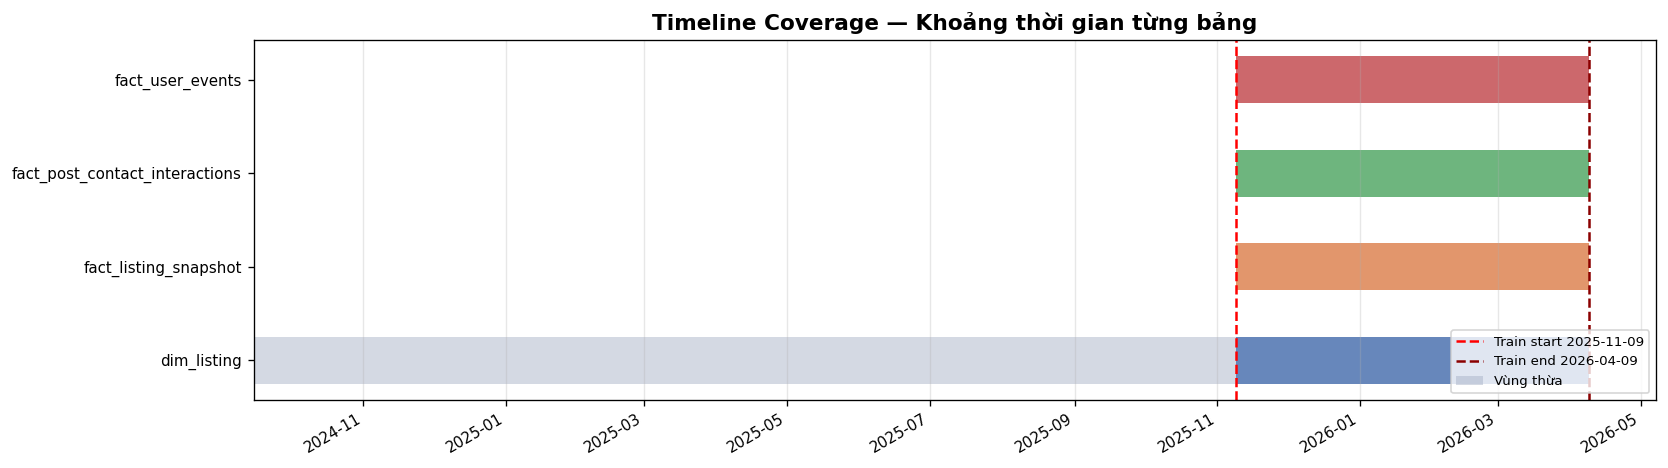

  Saved: /Users/ngoquanghuy/Documents/Datathon_Data/outputs/1050/z1_timeline_gantt.png


In [3]:
# ZONE 1.2 — Chart 1: Timeline Gantt
fig, ax = plt.subplots(figsize=(14,4))
tbl_list = list(ranges.keys())
clrs = ['#4C72B0','#DD8452','#55A868','#C44E52']

for i,(tbl,(s,e)) in enumerate(ranges.items()):
    s_num = mdates.date2num(s.to_pydatetime())
    e_num = mdates.date2num(e.to_pydatetime())
    ws_num= mdates.date2num(WINDOW_START.to_pydatetime())
    if tbl == 'dim_listing' and s < WINDOW_START:
        ax.barh(i, ws_num-s_num, left=s_num, height=0.5, color='#aab4c8', alpha=0.5, label='Vùng thừa')
        ax.barh(i, e_num-ws_num, left=ws_num, height=0.5, color=clrs[i], alpha=0.85)
    else:
        ax.barh(i, e_num-s_num, left=s_num, height=0.5, color=clrs[i], alpha=0.85)

ax.axvline(mdates.date2num(WINDOW_START.to_pydatetime()), color='red',     lw=1.5, ls='--', label='Train start 2025-11-09')
ax.axvline(mdates.date2num(WINDOW_END.to_pydatetime()),   color='darkred', lw=1.5, ls='--', label='Train end 2026-04-09')
ax.set_yticks(range(len(tbl_list))); ax.set_yticklabels(tbl_list, fontsize=9)
ax.xaxis_date(); ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=30, ha='right')
ax.set_title('Timeline Coverage — Khoảng thời gian từng bảng', fontweight='bold')
ax.legend(loc='lower right', fontsize=8); ax.grid(axis='x', alpha=0.3)
plt.tight_layout(); save_fig("z1_timeline_gantt.png")

Tính mật độ theo tuần...


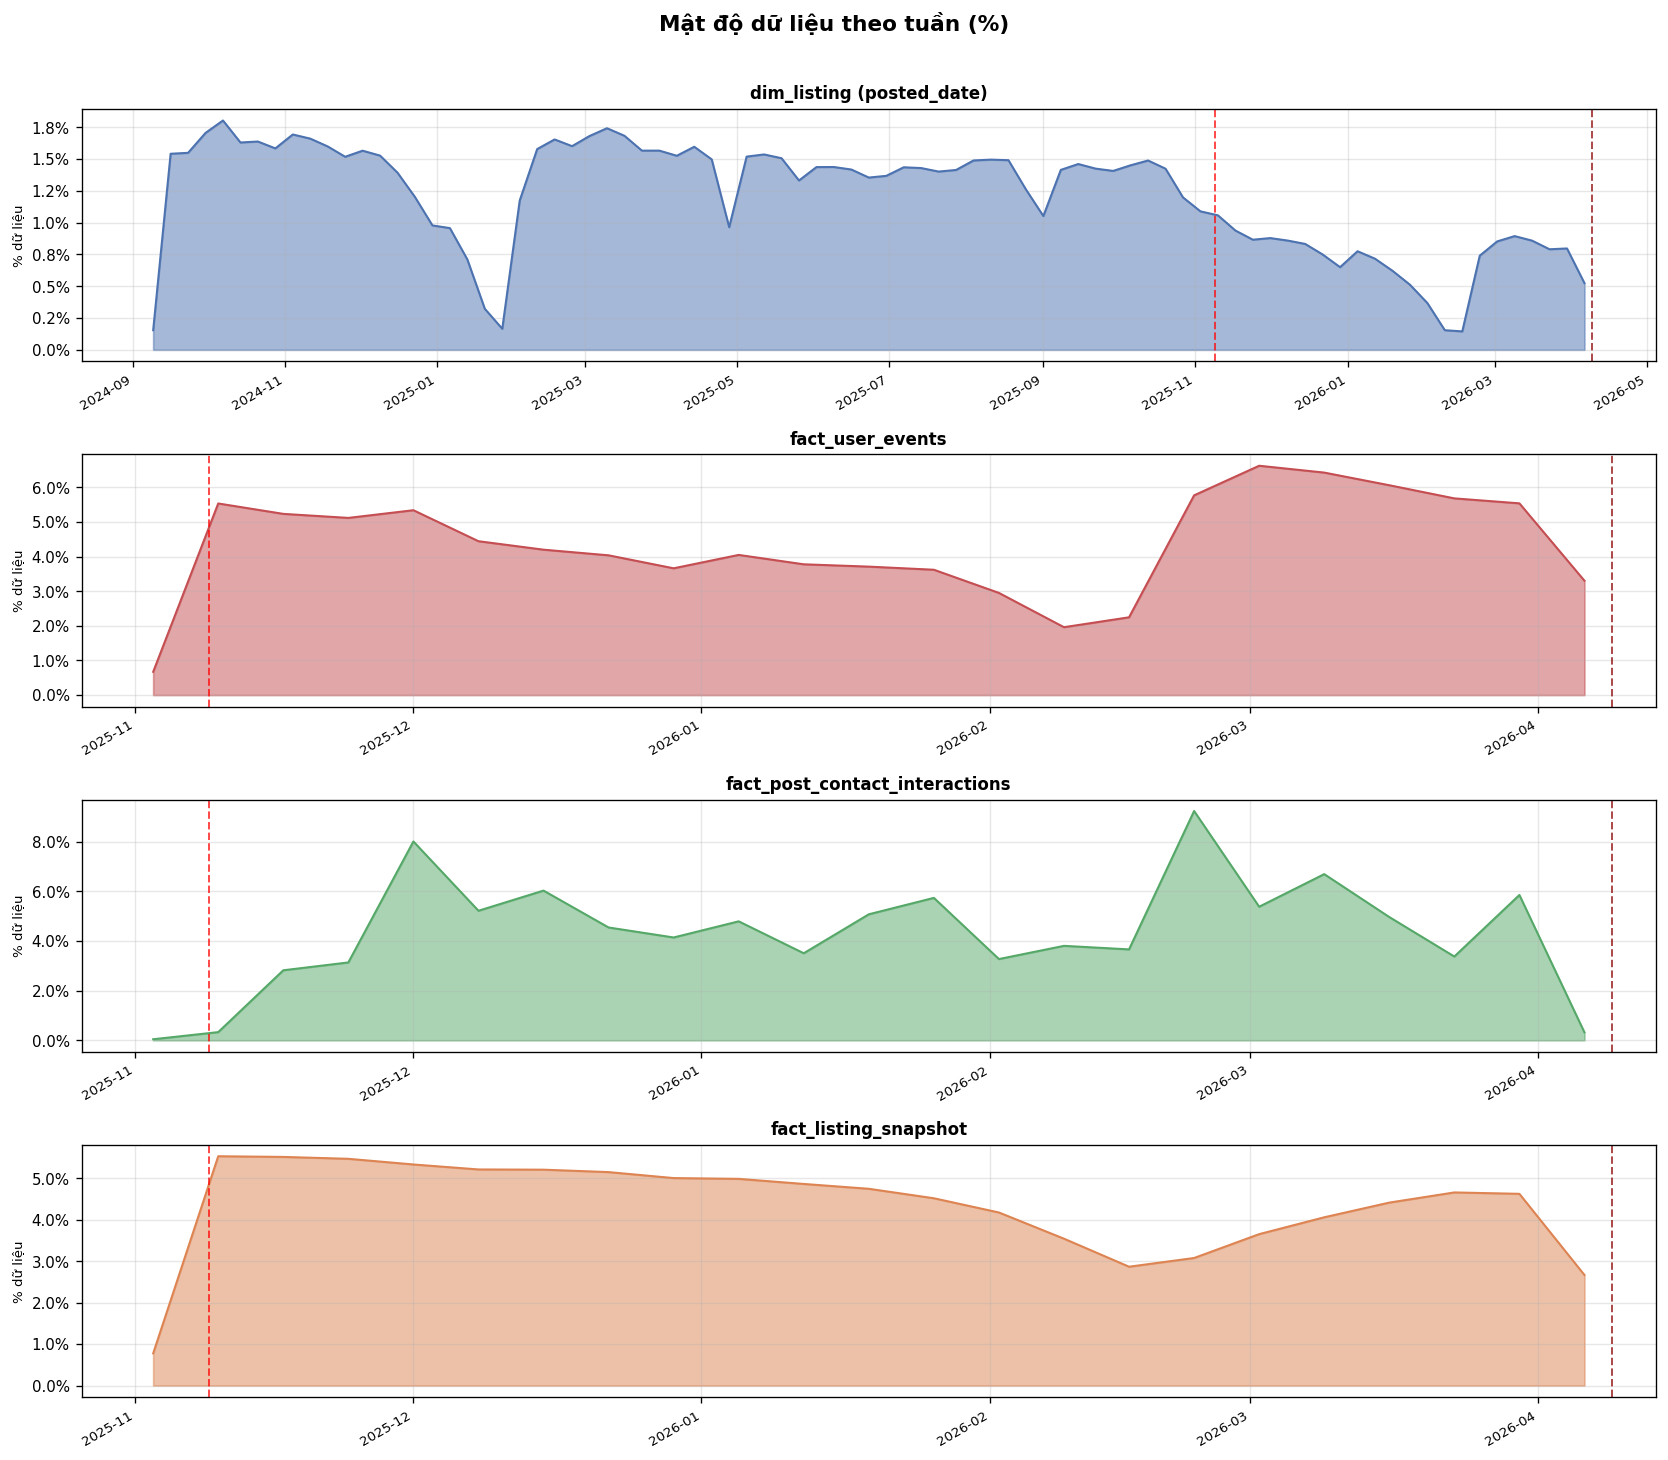

  Saved: /Users/ngoquanghuy/Documents/Datathon_Data/outputs/1050/z1_data_density.png


In [4]:
# ZONE 1.3 — Chart 2: Mật độ dữ liệu theo tuần (%)
print("Tính mật độ theo tuần...")
con = duckdb.connect(); con.execute("SET memory_limit='6GB'; SET threads=4")

dim_w = df_dim.groupby(df_dim['posted_date'].dt.to_period('W').apply(lambda x: x.start_time)).size().reset_index()
dim_w.columns = ['week','count']; dim_w['pct'] = dim_w['count']/dim_w['count'].sum()*100

def weekly_q(path, label):
    sql = "SELECT DATE_TRUNC('week', CAST(date AS DATE)) as week, COUNT(*) as cnt FROM read_parquet('" + path + "*.parquet') GROUP BY 1 ORDER BY 1"
    df = con.execute(sql).df(); df['pct'] = df['cnt']/df['cnt'].sum()*100; return df

snap_w  = weekly_q(SNAP_PATH,'snap')
inter_w = weekly_q(INTER_PATH,'inter')
ev_w    = weekly_q(EVENTS_PATH,'ev')
con.close()

fig, axes = plt.subplots(4,1,figsize=(14,12))
datasets = [(dim_w,'dim_listing (posted_date)','#4C72B0'),
            (ev_w,'fact_user_events','#C44E52'),
            (inter_w,'fact_post_contact_interactions','#55A868'),
            (snap_w,'fact_listing_snapshot','#DD8452')]

for ax,(df,title,color) in zip(axes,datasets):
    df['week'] = pd.to_datetime(df['week'])
    ax.fill_between(df['week'],df['pct'],color=color,alpha=0.5)
    ax.plot(df['week'],df['pct'],color=color,lw=1.2)
    ax.axvline(WINDOW_START,color='red',lw=1.2,ls='--',alpha=0.7)
    ax.axvline(WINDOW_END,  color='darkred',lw=1.2,ls='--',alpha=0.7)
    ax.set_title(title,fontsize=10,fontweight='bold'); ax.set_ylabel('% dữ liệu',fontsize=8)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(pct_fmt))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.setp(ax.xaxis.get_majorticklabels(),rotation=30,ha='right',fontsize=8); ax.grid(alpha=0.3)

fig.suptitle('Mật độ dữ liệu theo tuần (%)',fontweight='bold',fontsize=13,y=1.01)
plt.tight_layout(); save_fig("z1_data_density.png")

In [5]:
# ZONE 1.4 — Cắt align về cửa sổ chung
n_before = len(df_dim)
mask = ((df_dim['posted_date'] <= WINDOW_END) &
        (df_dim['expected_expired_date'].isna() | (df_dim['expected_expired_date'] >= WINDOW_START)))
df_dim_clean = df_dim[mask].copy()
valid_items  = set(df_dim_clean['item_id'])
n_after = len(df_dim_clean)

print(f"{'Bảng':<45} {'Trước':>10} {'Sau':>10} {'% giảm':>8}")
print("-"*76)
print(f"{'dim_listing':<45} {n_before:>10,} {n_after:>10,} {(n_before-n_after)/n_before*100:>7.1f}%")
print(f"{'fact_* (filter item_id)':<45} {'(lazy)':>10} {'(lazy)':>10}")
print(f"\ndf_dim_clean: {len(df_dim_clean):,} | valid_items: {len(valid_items):,}")

cut_df = pd.DataFrame([{'bang':'dim_listing','rows_before':n_before,'rows_after':n_after,
                         'pct_giam':round((n_before-n_after)/n_before*100,2)}])
save_csv(cut_df,"z1_cut_summary.csv")

Bảng                                               Trước        Sau   % giảm
----------------------------------------------------------------------------
dim_listing                                    3,107,114    657,699    78.8%
fact_* (filter item_id)                           (lazy)     (lazy)

df_dim_clean: 657,699 | valid_items: 657,699
  Saved: /Users/ngoquanghuy/Documents/Datathon_Data/outputs/1050/z1_cut_summary.csv


---
# ZONE 2 — Category Split & Benchmark Panel

In [6]:
# ZONE 2.1 — Tạo filter per category
cat_sets = {}
for cat_id in CAT_MAPPING:
    cat_sets[cat_id] = set(df_dim_clean[df_dim_clean['category']==cat_id]['item_id'])
df_dim_focus = df_dim_clean[df_dim_clean['category']==CAT_FOCUS].copy()

print("Số tin đăng sau cắt timeline:")
for cat_id,cat_name in CAT_MAPPING.items():
    n = len(cat_sets[cat_id]); pct = n/len(df_dim_clean)*100
    marker = " <- FOCUS" if cat_id==CAT_FOCUS else ""
    print(f"  {cat_id} {cat_name:<25} {n:>8,}  ({pct:.1f}%){marker}")
print(f"  Tổng: {len(df_dim_clean):,}")

Số tin đăng sau cắt timeline:
  1010 Căn hộ / Chung cư          127,215  (19.3%)
  1020 Nhà ở                      310,926  (47.3%)
  1030 Văn phòng / Mặt bằng        55,088  (8.4%)
  1040 Đất                         78,844  (12.0%)
  1050 Phòng trọ                   85,626  (13.0%) <- FOCUS
  Tổng: 657,699


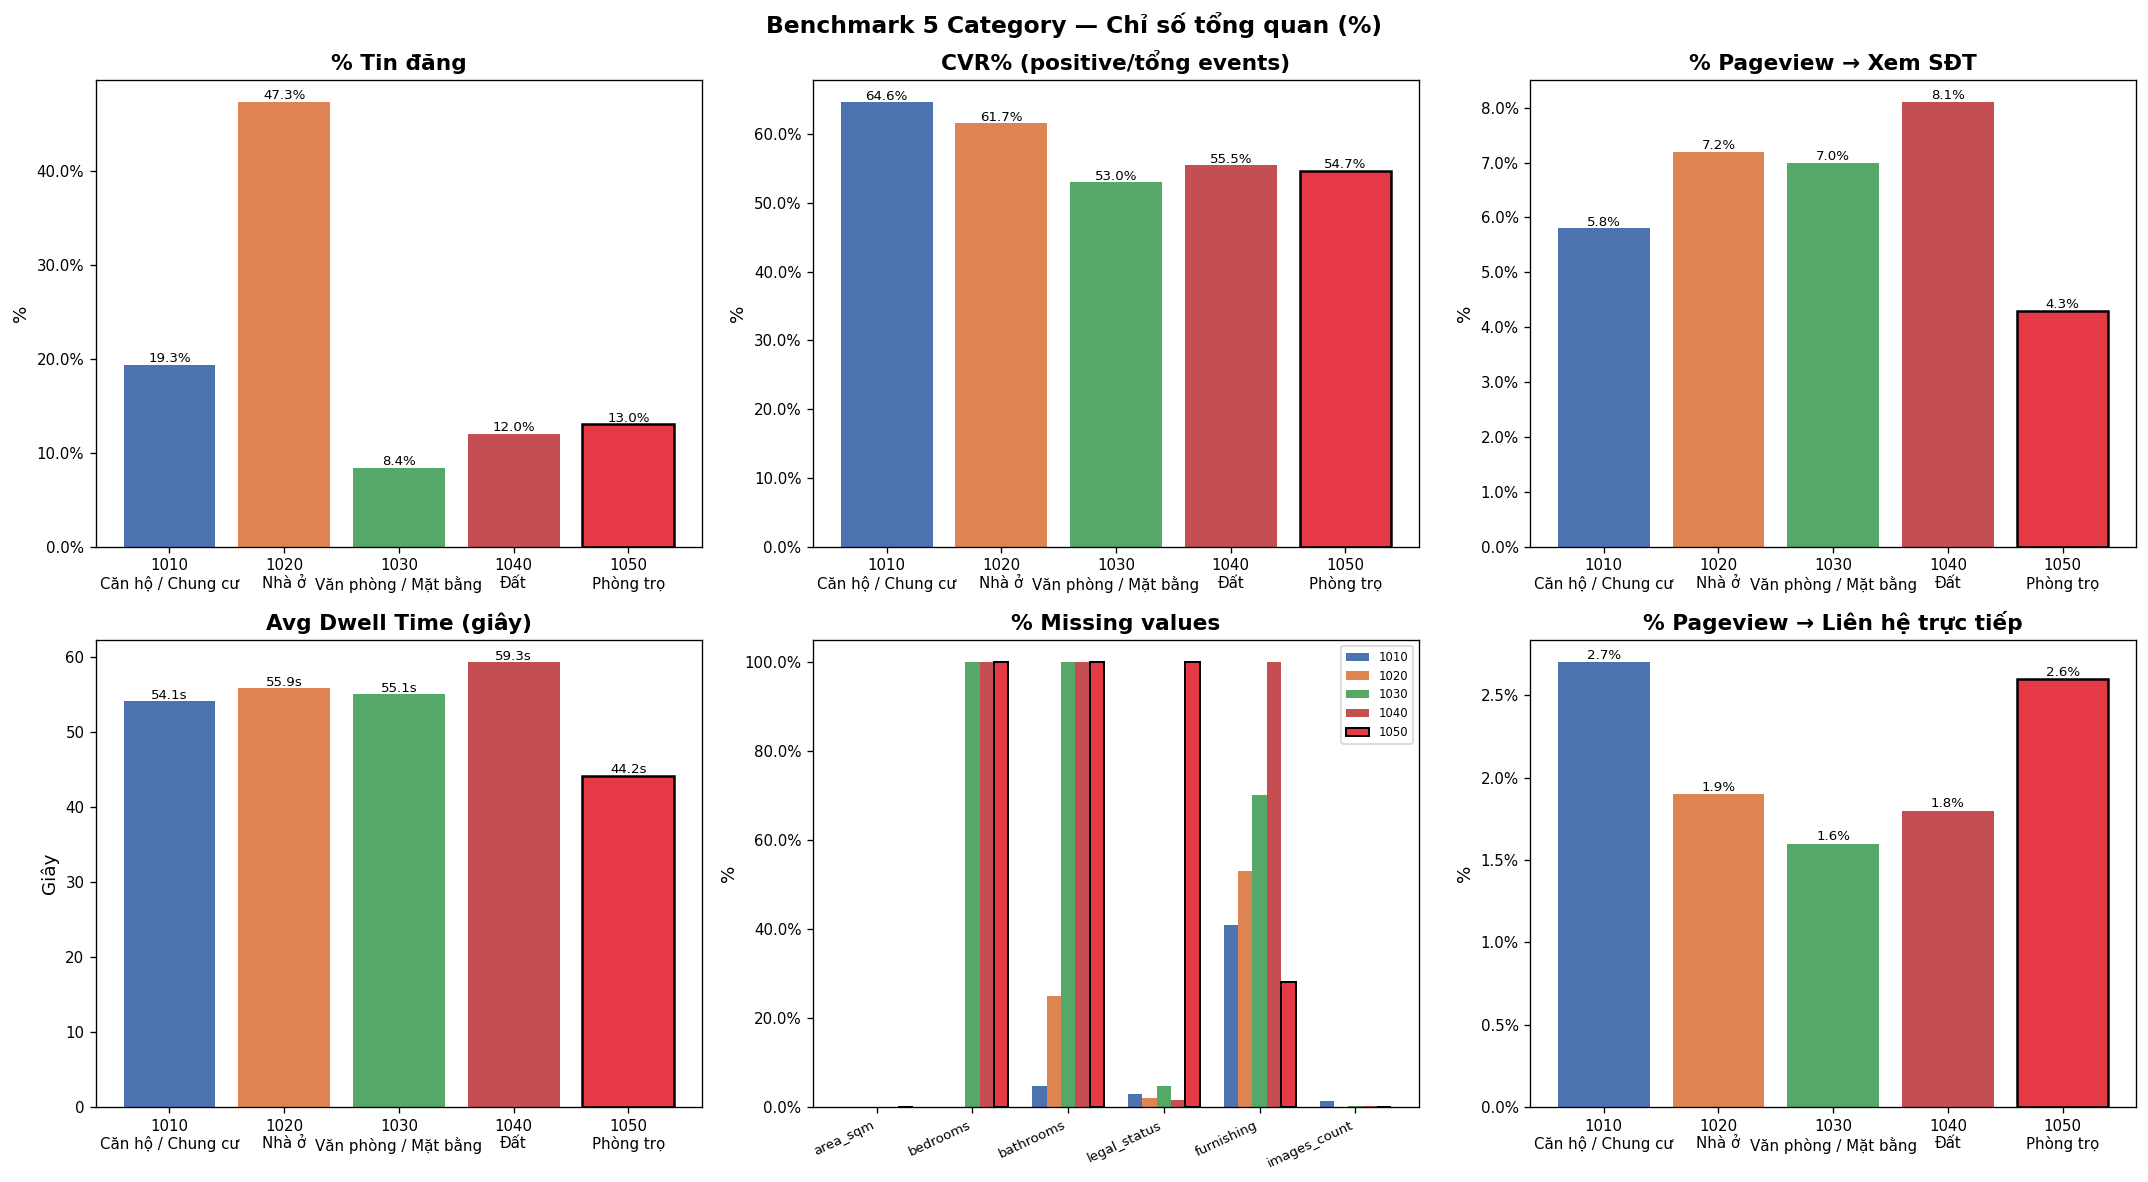

  Saved: /Users/ngoquanghuy/Documents/Datathon_Data/outputs/1050/z2_category_benchmark.png


In [7]:
# ZONE 2.2 — Benchmark panel 5 category
s2_cvr    = pd.read_csv(BASE+"/outputs/s2_cvr.csv")
s2_funnel = pd.read_csv(BASE+"/outputs/s2_funnel.csv")
s2_dwell  = pd.read_csv(BASE+"/outputs/s2_dwell_time.csv")
s1_miss   = pd.read_csv(BASE+"/outputs/s1_missing_values.csv")

cats5      = [1010,1020,1030,1040,1050]
cat_labels = [f"{c}\n{CAT_MAPPING[c]}" for c in cats5]
clrs5      = [CAT_COLORS[c] for c in cats5]
edges5     = ['black' if c==CAT_FOCUS else 'none' for c in cats5]

fig, axes = plt.subplots(2,3,figsize=(18,10))
fig.suptitle('Benchmark 5 Category — Chỉ số tổng quan (%)',fontweight='bold',fontsize=14)

# 1: % tin đăng
ax = axes[0,0]
cnts = [len(cat_sets[c]) for c in cats5]; tot = sum(cnts); pcts=[v/tot*100 for v in cnts]
bars = ax.bar(cat_labels,pcts,color=clrs5,edgecolor=edges5,linewidth=1.5)
[ax.text(b.get_x()+b.get_width()/2,v+0.3,f"{v:.1f}%",ha='center',fontsize=8) for b,v in zip(bars,pcts)]
ax.yaxis.set_major_formatter(plt.FuncFormatter(pct_fmt)); ax.set_title('% Tin đăng',fontweight='bold'); ax.set_ylabel('%')

# 2: CVR%
ax = axes[0,1]
cvr_v = [s2_cvr[s2_cvr['category']==c]['CVR'].values[0] for c in cats5]
bars = ax.bar(cat_labels,cvr_v,color=clrs5,edgecolor=edges5,linewidth=1.5)
[ax.text(b.get_x()+b.get_width()/2,v+0.3,f"{v:.1f}%",ha='center',fontsize=8) for b,v in zip(bars,cvr_v)]
ax.yaxis.set_major_formatter(plt.FuncFormatter(pct_fmt)); ax.set_title('CVR% (positive/tổng events)',fontweight='bold'); ax.set_ylabel('%')

# 3: pv→phone%
ax = axes[0,2]
ph_v = [s2_funnel[s2_funnel['category']==c]['pv_to_phone'].values[0] for c in cats5]
bars = ax.bar(cat_labels,ph_v,color=clrs5,edgecolor=edges5,linewidth=1.5)
[ax.text(b.get_x()+b.get_width()/2,v+0.05,f"{v:.1f}%",ha='center',fontsize=8) for b,v in zip(bars,ph_v)]
ax.yaxis.set_major_formatter(plt.FuncFormatter(pct_fmt)); ax.set_title('% Pageview → Xem SĐT',fontweight='bold'); ax.set_ylabel('%')

# 4: Dwell time
ax = axes[1,0]
dw_v = [s2_dwell[s2_dwell['category']==c]['mean_dwell'].values[0] for c in cats5]
bars = ax.bar(cat_labels,dw_v,color=clrs5,edgecolor=edges5,linewidth=1.5)
[ax.text(b.get_x()+b.get_width()/2,v+0.3,f"{v:.1f}s",ha='center',fontsize=8) for b,v in zip(bars,dw_v)]
ax.set_title('Avg Dwell Time (giây)',fontweight='bold'); ax.set_ylabel('Giây')

# 5: Missing values
ax = axes[1,1]
key_cols=['area_sqm','bedrooms','bathrooms','legal_status','furnishing','images_count']
miss_piv = s1_miss[s1_miss['column'].isin(key_cols)].pivot_table(
    index='category',columns='column',values='null_pct',aggfunc='first').fillna(0).reindex(cats5)
x = np.arange(len(key_cols)); w = 0.15
for i,(cat_id,row) in enumerate(miss_piv.iterrows()):
    vals=[row.get(c,0) for c in key_cols]
    ec='black' if cat_id==CAT_FOCUS else 'none'
    ax.bar(x+i*w,vals,w,color=CAT_COLORS[cat_id],edgecolor=ec,linewidth=1.2,label=f"{cat_id}")
ax.set_xticks(x+w*2); ax.set_xticklabels(key_cols,rotation=25,ha='right',fontsize=8)
ax.yaxis.set_major_formatter(plt.FuncFormatter(pct_fmt)); ax.set_title('% Missing values',fontweight='bold')
ax.set_ylabel('%'); ax.legend(fontsize=7,loc='upper right')

# 6: pv→contact%
ax = axes[1,2]
co_v = [s2_funnel[s2_funnel['category']==c]['pv_to_contact'].values[0] for c in cats5]
bars = ax.bar(cat_labels,co_v,color=clrs5,edgecolor=edges5,linewidth=1.5)
[ax.text(b.get_x()+b.get_width()/2,v+0.02,f"{v:.1f}%",ha='center',fontsize=8) for b,v in zip(bars,co_v)]
ax.yaxis.set_major_formatter(plt.FuncFormatter(pct_fmt)); ax.set_title('% Pageview → Liên hệ trực tiếp',fontweight='bold'); ax.set_ylabel('%')

plt.tight_layout(); save_fig("z2_category_benchmark.png")

---
# ZONE 3 — Supply Analysis (dim_listing cho 1050)

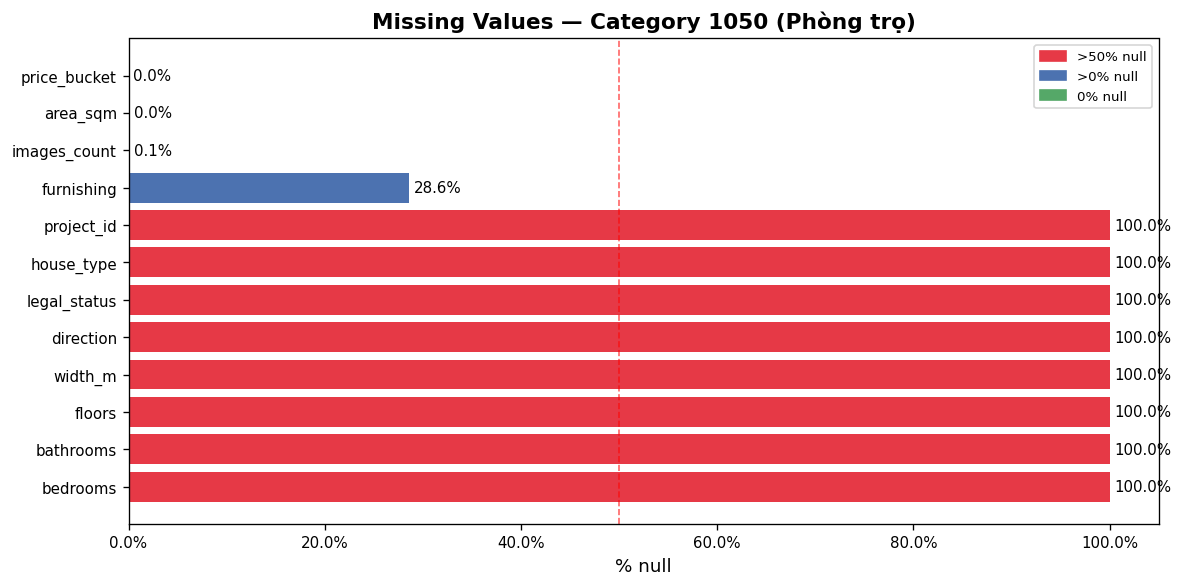

  Saved: /Users/ngoquanghuy/Documents/Datathon_Data/outputs/1050/z3_missing_values.png
  Saved: /Users/ngoquanghuy/Documents/Datathon_Data/outputs/1050/z3_missing_values.csv


In [8]:
# ZONE 3.1 — Missing values heatmap
all_cols=['area_sqm','bedrooms','bathrooms','floors','width_m','images_count',
          'direction','legal_status','house_type','furnishing','project_id','price_bucket']
miss_d = {c: df_dim_focus[c].isna().mean()*100 for c in all_cols if c in df_dim_focus.columns}
miss_df= pd.DataFrame({'column':list(miss_d.keys()),'null_pct':list(miss_d.values())}).sort_values('null_pct',ascending=False)

fig,ax = plt.subplots(figsize=(10,5))
bar_colors=['#E63946' if v>50 else '#4C72B0' if v>0 else '#55A868' for v in miss_df['null_pct']]
bars = ax.barh(miss_df['column'],miss_df['null_pct'],color=bar_colors)
ax.axvline(50,color='red',lw=1,ls='--',alpha=0.6)
[ax.text(v+0.5,b.get_y()+b.get_height()/2,f"{v:.1f}%",va='center',fontsize=9) for b,v in zip(bars,miss_df['null_pct'])]
ax.xaxis.set_major_formatter(plt.FuncFormatter(pct_fmt))
ax.set_title(f'Missing Values — Category {CAT_FOCUS} ({CAT_NAME})',fontweight='bold'); ax.set_xlabel('% null')
legend_p=[Patch(color='#E63946',label='>50% null'),Patch(color='#4C72B0',label='>0% null'),Patch(color='#55A868',label='0% null')]
ax.legend(handles=legend_p,fontsize=8); plt.tight_layout(); save_fig("z3_missing_values.png")
save_csv(miss_df,"z3_missing_values.csv")

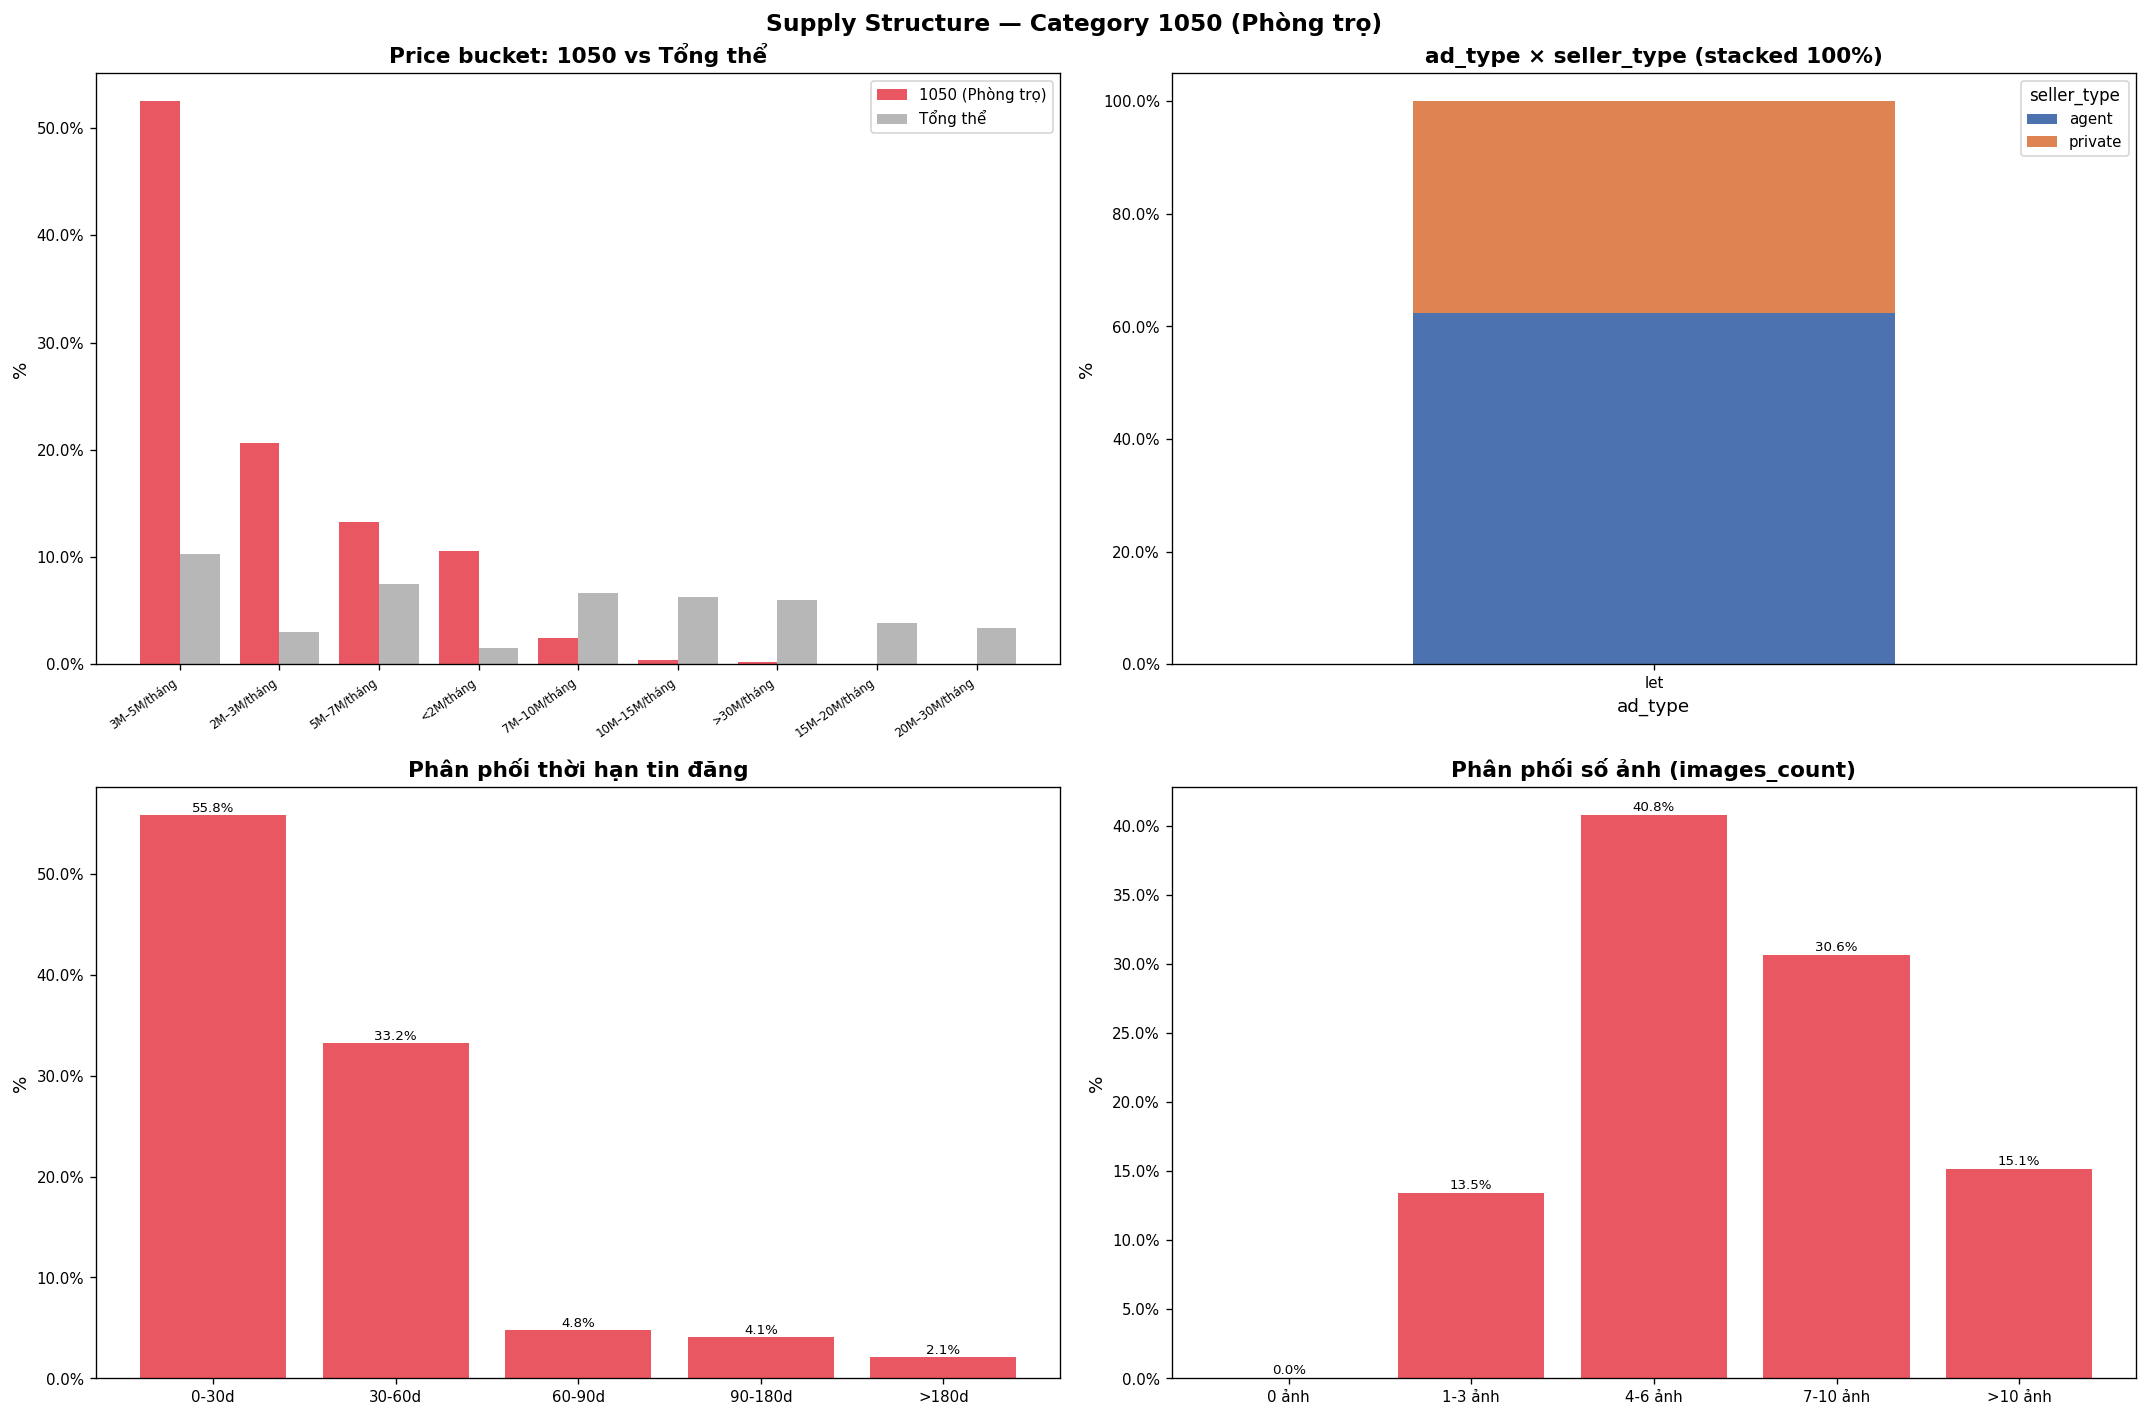

  Saved: /Users/ngoquanghuy/Documents/Datathon_Data/outputs/1050/z3_supply_structure.png
  Saved: /Users/ngoquanghuy/Documents/Datathon_Data/outputs/1050/z3_price_bucket.csv


In [9]:
# ZONE 3.2 — Price bucket + ad_type × seller_type + Duration + Images
fig,axes = plt.subplots(2,2,figsize=(18,12))
fig.suptitle(f'Supply Structure — Category {CAT_FOCUS} ({CAT_NAME})',fontweight='bold',fontsize=14)

# Price bucket comparison
ax = axes[0,0]
pb_1050 = df_dim_focus['price_bucket'].value_counts(normalize=True).mul(100).head(15)
pb_all  = df_dim_clean['price_bucket'].value_counts(normalize=True).mul(100)
pb_m = pb_1050.to_frame('pct_1050').join(pb_all.rename('pct_all'),how='left').fillna(0)
x=np.arange(len(pb_m)); w=0.4
ax.bar(x-w/2,pb_m['pct_1050'],w,color=CAT_COLORS[CAT_FOCUS],alpha=0.85,label=f'1050 ({CAT_NAME})')
ax.bar(x+w/2,pb_m['pct_all'], w,color='#999',alpha=0.7,label='Tổng thể')
ax.set_xticks(x); ax.set_xticklabels(pb_m.index,rotation=35,ha='right',fontsize=7)
ax.yaxis.set_major_formatter(plt.FuncFormatter(pct_fmt))
ax.set_title('Price bucket: 1050 vs Tổng thể',fontweight='bold'); ax.set_ylabel('%'); ax.legend(fontsize=9)

# ad_type x seller_type stacked 100%
ax = axes[0,1]
cross = df_dim_focus.groupby(['ad_type','seller_type']).size().unstack(fill_value=0)
cross_pct = cross.div(cross.sum(axis=1),axis=0)*100
cross_pct.plot(kind='bar',stacked=True,ax=ax,color=['#4C72B0','#DD8452'],width=0.5)
ax.yaxis.set_major_formatter(plt.FuncFormatter(pct_fmt))
ax.set_title('ad_type × seller_type (stacked 100%)',fontweight='bold')
ax.set_ylabel('%'); ax.tick_params(axis='x',rotation=0); ax.legend(title='seller_type',fontsize=9)

# Listing duration
ax = axes[1,0]
df_dim_focus['duration_d'] = (df_dim_focus['expected_expired_date']-df_dim_focus['posted_date']).dt.days
dur_b=['0-30d','30-60d','60-90d','90-180d','>180d']
dur_pct = pd.cut(df_dim_focus['duration_d'],[0,30,60,90,180,1e9],labels=dur_b).value_counts(normalize=True).mul(100).reindex(dur_b)
bars=ax.bar(dur_b,dur_pct.values,color=CAT_COLORS[CAT_FOCUS],alpha=0.85)
[ax.text(b.get_x()+b.get_width()/2,v+0.3,f"{v:.1f}%",ha='center',fontsize=8) for b,v in zip(bars,dur_pct.values) if not np.isnan(v)]
ax.yaxis.set_major_formatter(plt.FuncFormatter(pct_fmt))
ax.set_title('Phân phối thời hạn tin đăng',fontweight='bold'); ax.set_ylabel('%')

# Images count
ax = axes[1,1]
img_b=['0 ảnh','1-3 ảnh','4-6 ảnh','7-10 ảnh','>10 ảnh']
img_pct=pd.cut(df_dim_focus['images_count'],[-1,0,3,6,10,1e9],labels=img_b).value_counts(normalize=True).mul(100).reindex(img_b)
bars=ax.bar(img_b,img_pct.values,color=CAT_COLORS[CAT_FOCUS],alpha=0.85)
[ax.text(b.get_x()+b.get_width()/2,v+0.3,f"{v:.1f}%",ha='center',fontsize=8) for b,v in zip(bars,img_pct.values) if not np.isnan(v)]
ax.yaxis.set_major_formatter(plt.FuncFormatter(pct_fmt))
ax.set_title('Phân phối số ảnh (images_count)',fontweight='bold'); ax.set_ylabel('%')

plt.tight_layout(); save_fig("z3_supply_structure.png")
save_csv(pb_m.reset_index(),"z3_price_bucket.csv")

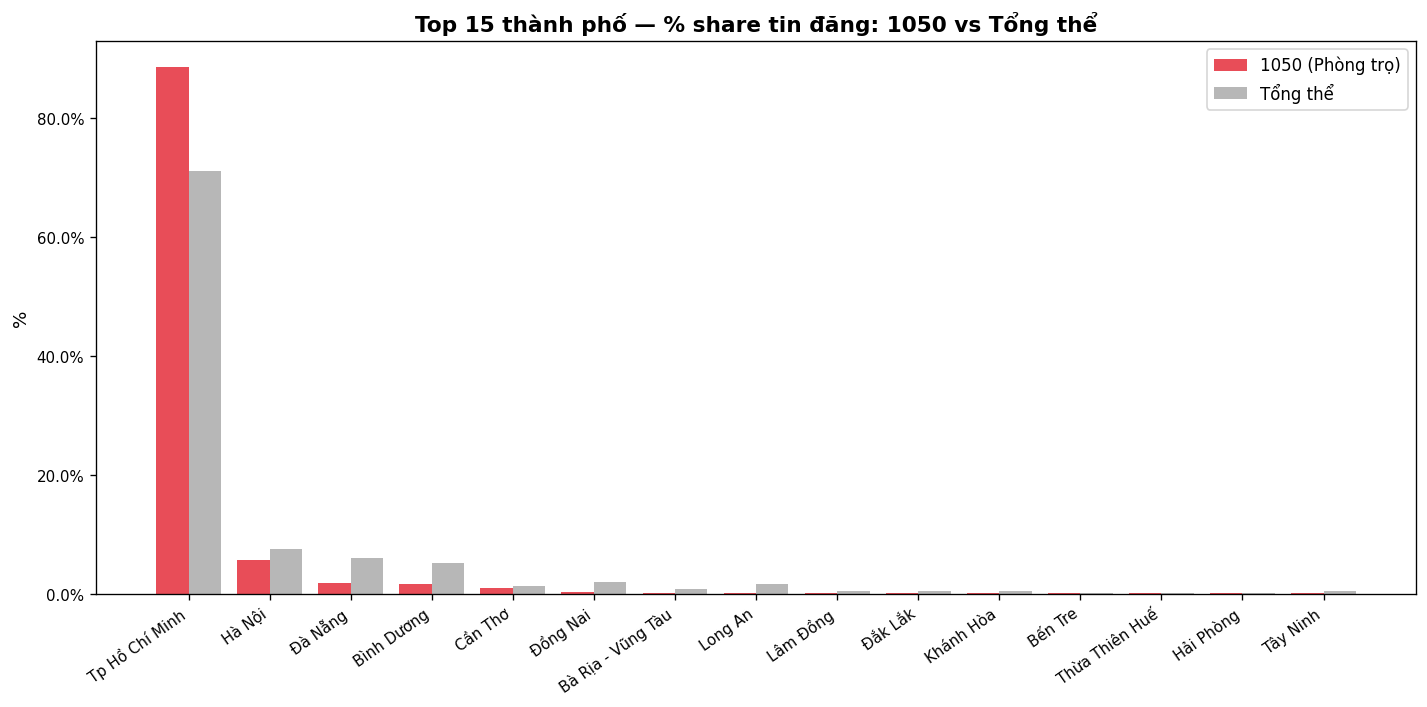

  Saved: /Users/ngoquanghuy/Documents/Datathon_Data/outputs/1050/z3_geo_supply.png
  Saved: /Users/ngoquanghuy/Documents/Datathon_Data/outputs/1050/z3_geo_supply.csv


In [10]:
# ZONE 3.3 — Geo supply top 15 city
geo_1050 = df_dim_focus['city_name'].value_counts(normalize=True).mul(100).head(15).reset_index()
geo_1050.columns=['city_name','pct_1050']
geo_all  = df_dim_clean['city_name'].value_counts(normalize=True).mul(100).reset_index()
geo_all.columns=['city_name','pct_total']
geo = geo_1050.merge(geo_all,on='city_name',how='left').fillna(0)

fig,ax = plt.subplots(figsize=(12,6))
x=np.arange(len(geo)); w=0.4
ax.bar(x-w/2,geo['pct_1050'], w,color=CAT_COLORS[CAT_FOCUS],alpha=0.9, label=f'1050 ({CAT_NAME})')
ax.bar(x+w/2,geo['pct_total'],w,color='#999',alpha=0.7,label='Tổng thể')
ax.set_xticks(x); ax.set_xticklabels(geo['city_name'],rotation=35,ha='right',fontsize=9)
ax.yaxis.set_major_formatter(plt.FuncFormatter(pct_fmt))
ax.set_title('Top 15 thành phố — % share tin đăng: 1050 vs Tổng thể',fontweight='bold')
ax.set_ylabel('%'); ax.legend()
plt.tight_layout(); save_fig("z3_geo_supply.png")
save_csv(geo,"z3_geo_supply.csv")

---
# ZONE 4 — Seller Analysis

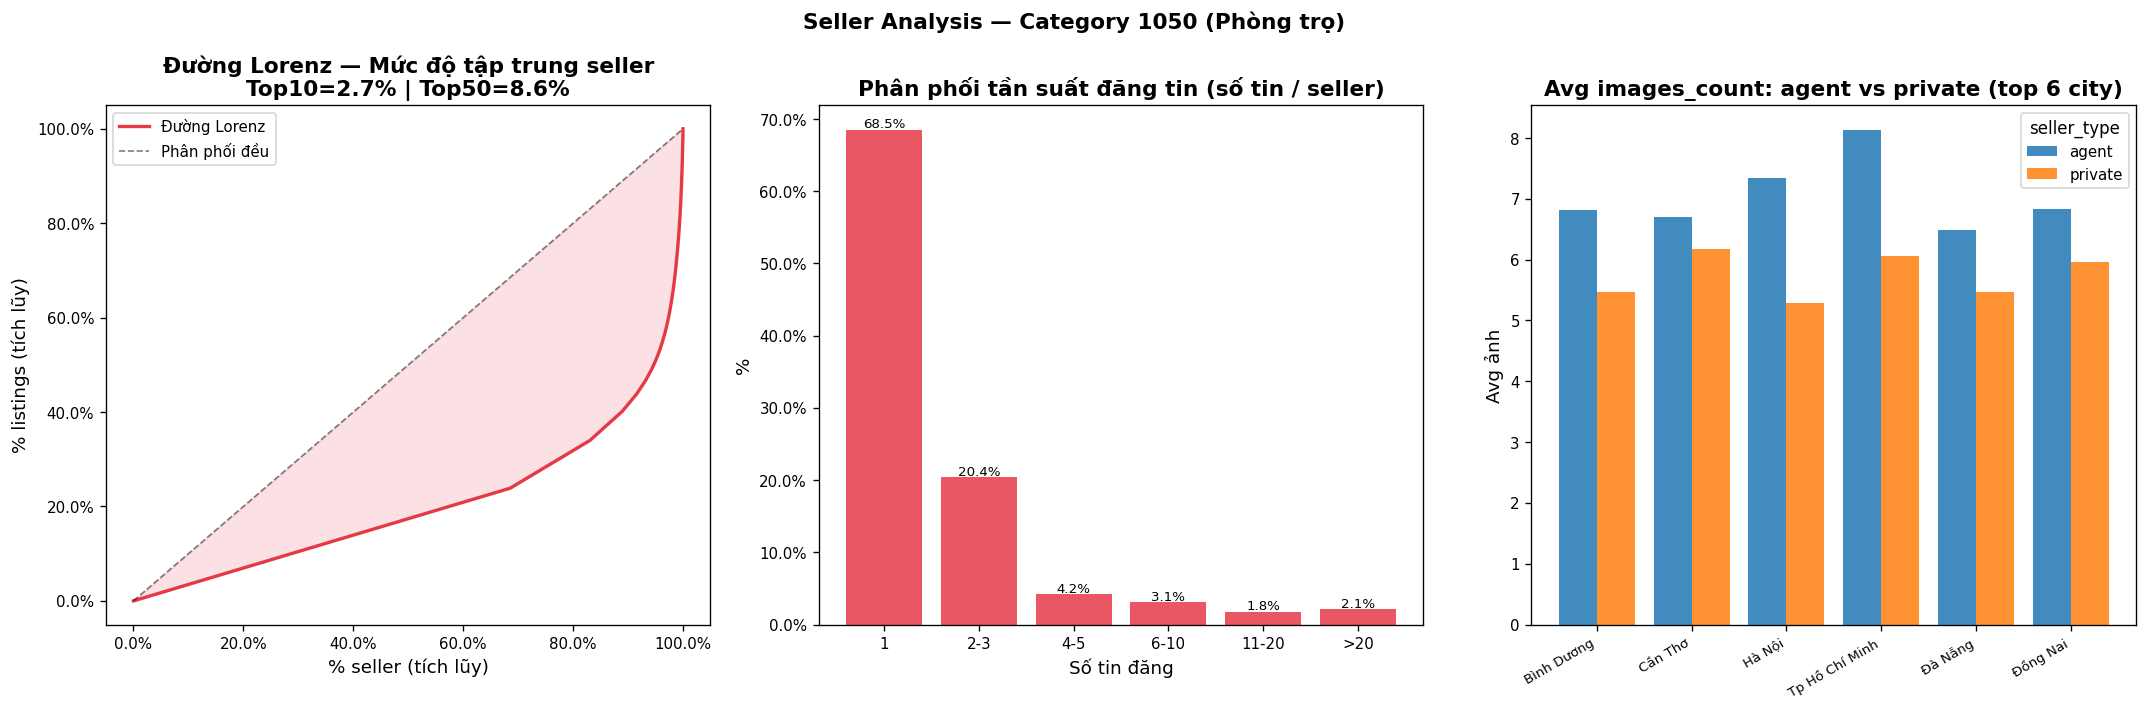

  Saved: /Users/ngoquanghuy/Documents/Datathon_Data/outputs/1050/z4_seller.png
  Saved: /Users/ngoquanghuy/Documents/Datathon_Data/outputs/1050/z4_top_sellers.csv


In [11]:
# ZONE 4 — Seller concentration + Posting frequency
seller_counts = df_dim_focus['seller_id'].value_counts().reset_index()
seller_counts.columns = ['seller_id','n_listings']
total_lst = len(df_dim_focus)
top10_pct = seller_counts.head(10)['n_listings'].sum()/total_lst*100
top50_pct = seller_counts.head(50)['n_listings'].sum()/total_lst*100

fig,axes = plt.subplots(1,3,figsize=(18,6))
fig.suptitle(f'Seller Analysis — Category {CAT_FOCUS} ({CAT_NAME})',fontweight='bold',fontsize=13)

# Lorenz curve
ax = axes[0]
sc = seller_counts['n_listings'].values[::-1]
cum_s = np.arange(1,len(sc)+1)/len(sc)*100
cum_l = np.cumsum(sc)/sc.sum()*100
ax.plot(cum_s,cum_l,color=CAT_COLORS[CAT_FOCUS],lw=2,label='Đường Lorenz')
ax.plot([0,100],[0,100],'k--',lw=1,alpha=0.5,label='Phân phối đều')
ax.fill_between(cum_s,cum_l,cum_s,alpha=0.15,color=CAT_COLORS[CAT_FOCUS])
ax.set_xlabel('% seller (tích lũy)'); ax.set_ylabel('% listings (tích lũy)')
ax.set_title(f'Đường Lorenz — Mức độ tập trung seller\nTop10={top10_pct:.1f}% | Top50={top50_pct:.1f}%',fontweight='bold')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(plt.FuncFormatter(pct_fmt))
ax.yaxis.set_major_formatter(plt.FuncFormatter(pct_fmt))

# Posting frequency histogram
ax = axes[1]
freq_b=['1','2-3','4-5','6-10','11-20','>20']
freq_pct=pd.cut(seller_counts['n_listings'],[0,1,3,5,10,20,1e9],labels=freq_b).value_counts(normalize=True).mul(100).reindex(freq_b)
bars=ax.bar(freq_b,freq_pct.values,color=CAT_COLORS[CAT_FOCUS],alpha=0.85)
[ax.text(b.get_x()+b.get_width()/2,v+0.3,f"{v:.1f}%",ha='center',fontsize=8) for b,v in zip(bars,freq_pct.values) if not np.isnan(v)]
ax.yaxis.set_major_formatter(plt.FuncFormatter(pct_fmt))
ax.set_title('Phân phối tần suất đăng tin (số tin / seller)',fontweight='bold')
ax.set_ylabel('%'); ax.set_xlabel('Số tin đăng')

# Agent vs private avg images per city
ax = axes[2]
top_cities = df_dim_focus['city_name'].value_counts().head(6).index
img_piv = df_dim_focus[df_dim_focus['city_name'].isin(top_cities)].groupby(['city_name','seller_type'])['images_count'].mean().unstack(fill_value=0)
x=np.arange(len(img_piv)); w=0.4
for i,col in enumerate(img_piv.columns):
    ax.bar(x+i*w-w*(len(img_piv.columns)-1)/2,img_piv[col],w,label=col,alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(img_piv.index,rotation=30,ha='right',fontsize=8)
ax.set_title('Avg images_count: agent vs private (top 6 city)',fontweight='bold')
ax.set_ylabel('Avg ảnh'); ax.legend(title='seller_type',fontsize=9)

plt.tight_layout(); save_fig("z4_seller.png")
save_csv(seller_counts.head(50),"z4_top_sellers.csv")

---
# ZONE 5 — Demand & Funnel Analysis (fact_user_events)

> Zone này query ~40GB — mất khoảng 5-10 phút.

In [12]:
# ZONE 5.1 — Load events 1050 via DuckDB
print("Query fact_user_events category=1050...")
t0 = time.time()
con = duckdb.connect(); con.execute("SET memory_limit='7GB'; SET threads=4")

sql = ("SELECT event_type, is_login, device,"
       " EXTRACT(hour FROM event_ts) AS hour,"
       " EXTRACT(dow  FROM event_ts) AS dow,"
       " date, is_contact, surface,"
       " (query IS NOT NULL) AS has_query,"
       " LEAST(GREATEST(CAST(COALESCE(position,0) AS INT),1),30) AS pos_bucket,"
       " CASE WHEN dwell_time_sec IS NULL THEN NULL"
       "      WHEN dwell_time_sec <  10   THEN '<10s'"
       "      WHEN dwell_time_sec <  30   THEN '10-30s'"
       "      WHEN dwell_time_sec <  60   THEN '30-60s'"
       "      WHEN dwell_time_sec < 120   THEN '1-2min'"
       "      WHEN dwell_time_sec < 300   THEN '2-5min'"
       "      ELSE '>5min' END AS dwell_bucket"
       " FROM read_parquet('" + EVENTS_PATH + "*.parquet')"
       " WHERE category = " + str(CAT_FOCUS))

ev = con.execute(sql).df()
con.close()
print(f"Loaded {len(ev):,} events 1050 | {time.time()-t0:.0f}s")

Query fact_user_events category=1050...
Loaded 40,807,177 events 1050 | 270s


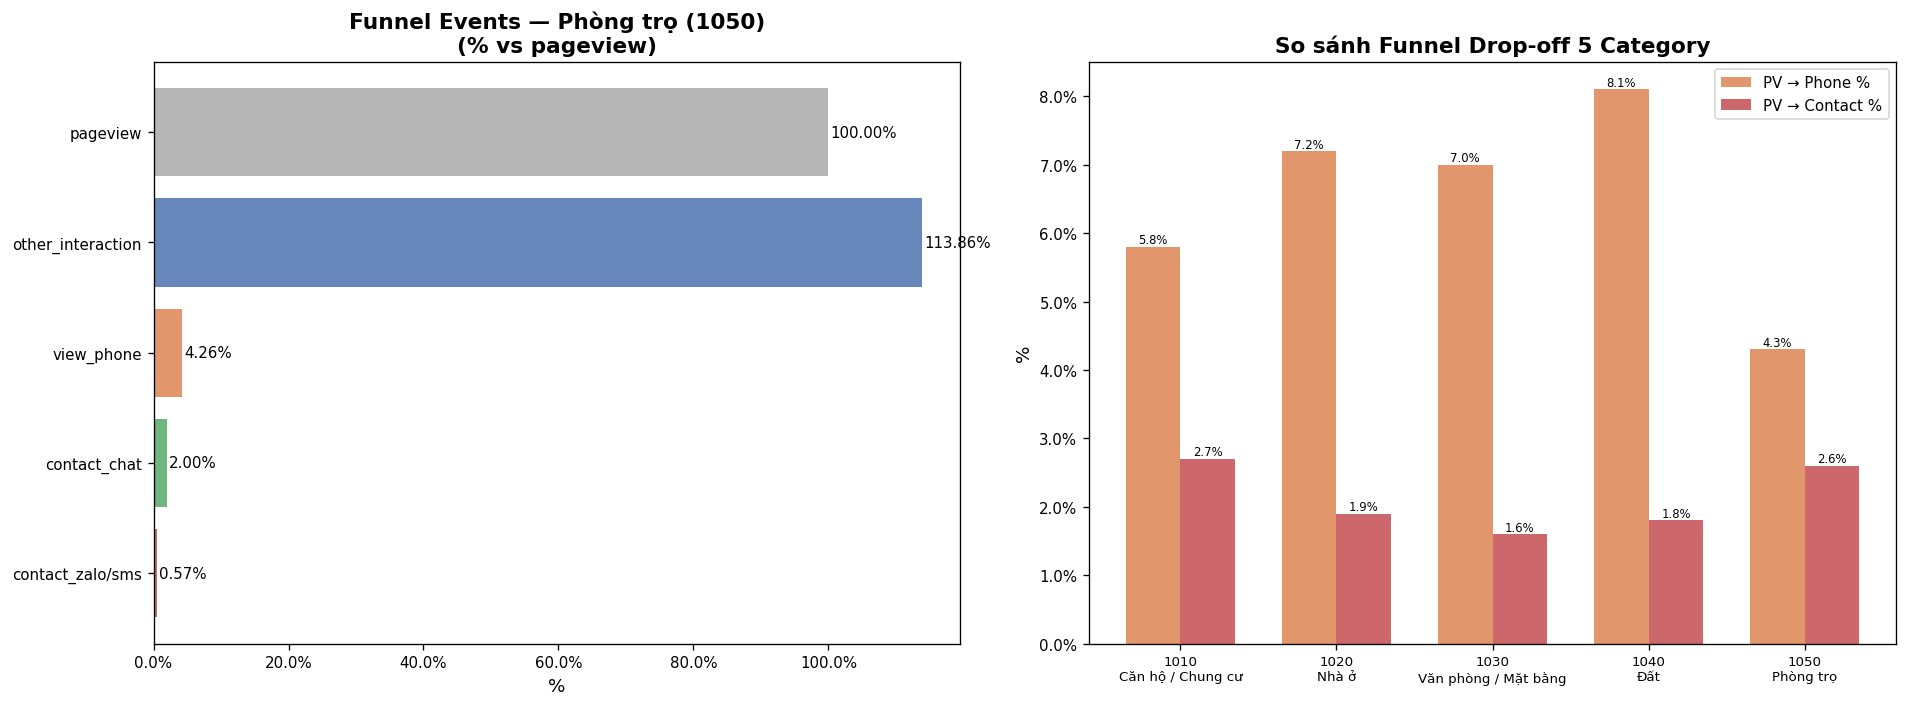

  Saved: /Users/ngoquanghuy/Documents/Datathon_Data/outputs/1050/z5_funnel.png
  Saved: /Users/ngoquanghuy/Documents/Datathon_Data/outputs/1050/z5_funnel_1050.csv


In [13]:
# ZONE 5.2 — Funnel waterfall
s2_funnel_df = pd.read_csv(BASE+"/outputs/s2_funnel.csv")
fc = ev['event_type'].value_counts()
POSITIVE = ['other_interaction','view_phone','contact_chat','contact_zalo','contact_sms']

steps  = ['pageview','other_interaction','view_phone','contact_chat','contact_zalo/sms']
values = [fc.get('pageview',0), fc.get('other_interaction',0), fc.get('view_phone',0),
          fc.get('contact_chat',0), fc.get('contact_zalo',0)+fc.get('contact_sms',0)]
top = values[0] if values[0]>0 else 1
pcts= [v/top*100 for v in values]

fig,axes = plt.subplots(1,2,figsize=(16,6))

ax = axes[0]
bar_fc=['#aaa','#4C72B0','#DD8452','#55A868','#C44E52']
bars = ax.barh(steps[::-1],pcts[::-1],color=bar_fc[::-1],alpha=0.85)
[ax.text(v+0.3,b.get_y()+b.get_height()/2,f"{v:.2f}%",va='center',fontsize=9) for b,v in zip(bars,pcts[::-1])]
ax.xaxis.set_major_formatter(plt.FuncFormatter(pct_fmt))
ax.set_title(f'Funnel Events — {CAT_NAME} (1050)\n(% vs pageview)',fontweight='bold'); ax.set_xlabel('%')

ax = axes[1]
cats5=[1010,1020,1030,1040,1050]; cat_l=[f"{c}\n{CAT_MAPPING[c]}" for c in cats5]
ph_=[s2_funnel_df[s2_funnel_df['category']==c]['pv_to_phone'].values[0] for c in cats5]
co_=[s2_funnel_df[s2_funnel_df['category']==c]['pv_to_contact'].values[0] for c in cats5]
x=np.arange(len(cats5)); w=0.35
ax.bar(x-w/2,ph_,w,color='#DD8452',alpha=0.85,label='PV → Phone %')
ax.bar(x+w/2,co_,w,color='#C44E52',alpha=0.85,label='PV → Contact %')
ax.set_xticks(x); ax.set_xticklabels(cat_l,fontsize=8)
ax.yaxis.set_major_formatter(plt.FuncFormatter(pct_fmt))
ax.set_title('So sánh Funnel Drop-off 5 Category',fontweight='bold'); ax.set_ylabel('%'); ax.legend(fontsize=9)
[ax.text(x[i]-w/2,v+0.05,f"{v:.1f}%",ha='center',fontsize=7) for i,v in enumerate(ph_)]
[ax.text(x[i]+w/2,v+0.05,f"{v:.1f}%",ha='center',fontsize=7) for i,v in enumerate(co_)]

plt.tight_layout(); save_fig("z5_funnel.png")
funnel_df=pd.DataFrame({'buoc':steps,'count':values,'pct_vs_pageview':pcts})
save_csv(funnel_df,"z5_funnel_1050.csv")

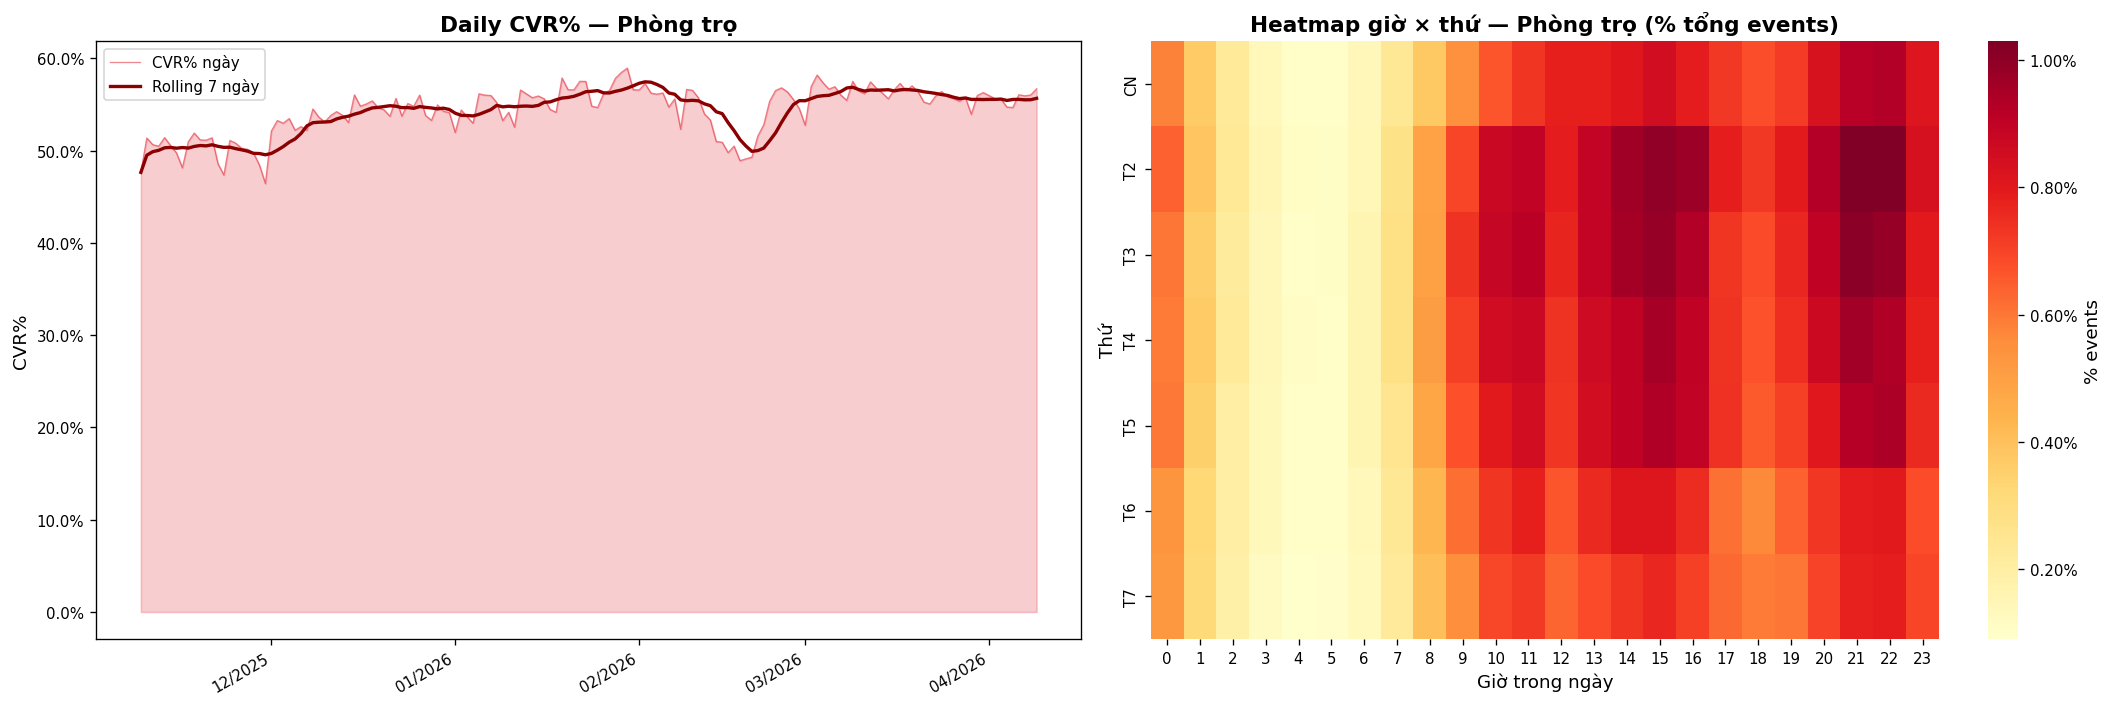

  Saved: /Users/ngoquanghuy/Documents/Datathon_Data/outputs/1050/z5_daily_heatmap.png
  Saved: /Users/ngoquanghuy/Documents/Datathon_Data/outputs/1050/z5_daily_cvr.csv


In [14]:
# ZONE 5.3 — Daily CVR% + Heatmap giờ × thứ
daily = ev.groupby('date').agg(total=('event_type','count'),positive=('is_contact','sum')).reset_index()
daily['cvr'] = daily['positive']/daily['total']*100
daily['date']= pd.to_datetime(daily['date'])
daily = daily.sort_values('date')
daily['rolling7'] = daily['cvr'].rolling(7,min_periods=1).mean()

dow_m={0:'CN',1:'T2',2:'T3',3:'T4',4:'T5',5:'T6',6:'T7'}
ev['dow_name'] = ev['dow'].map(dow_m)
hm = ev.groupby(['dow','hour']).size().unstack(fill_value=0)
hm_pct = hm.div(hm.values.sum())*100
hm_pct.index = [dow_m.get(i,i) for i in hm_pct.index]

fig,axes=plt.subplots(1,2,figsize=(18,6))

ax=axes[0]
ax.fill_between(daily['date'],daily['cvr'],alpha=0.25,color=CAT_COLORS[CAT_FOCUS])
ax.plot(daily['date'],daily['cvr'],lw=0.8,color=CAT_COLORS[CAT_FOCUS],alpha=0.6,label='CVR% ngày')
ax.plot(daily['date'],daily['rolling7'],lw=2,color='darkred',label='Rolling 7 ngày')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%Y'))
plt.setp(ax.xaxis.get_majorticklabels(),rotation=30,ha='right')
ax.yaxis.set_major_formatter(plt.FuncFormatter(pct_fmt))
ax.set_title(f'Daily CVR% — {CAT_NAME}',fontweight='bold'); ax.set_ylabel('CVR%'); ax.legend(fontsize=9)

ax=axes[1]
sns.heatmap(hm_pct,ax=ax,cmap='YlOrRd',fmt='.2f',cbar_kws={'label':'% events','format':'%.2f%%'})
ax.set_title(f'Heatmap giờ × thứ — {CAT_NAME} (% tổng events)',fontweight='bold')
ax.set_xlabel('Giờ trong ngày'); ax.set_ylabel('Thứ')

plt.tight_layout(); save_fig("z5_daily_heatmap.png")
save_csv(daily[['date','total','positive','cvr','rolling7']],"z5_daily_cvr.csv")

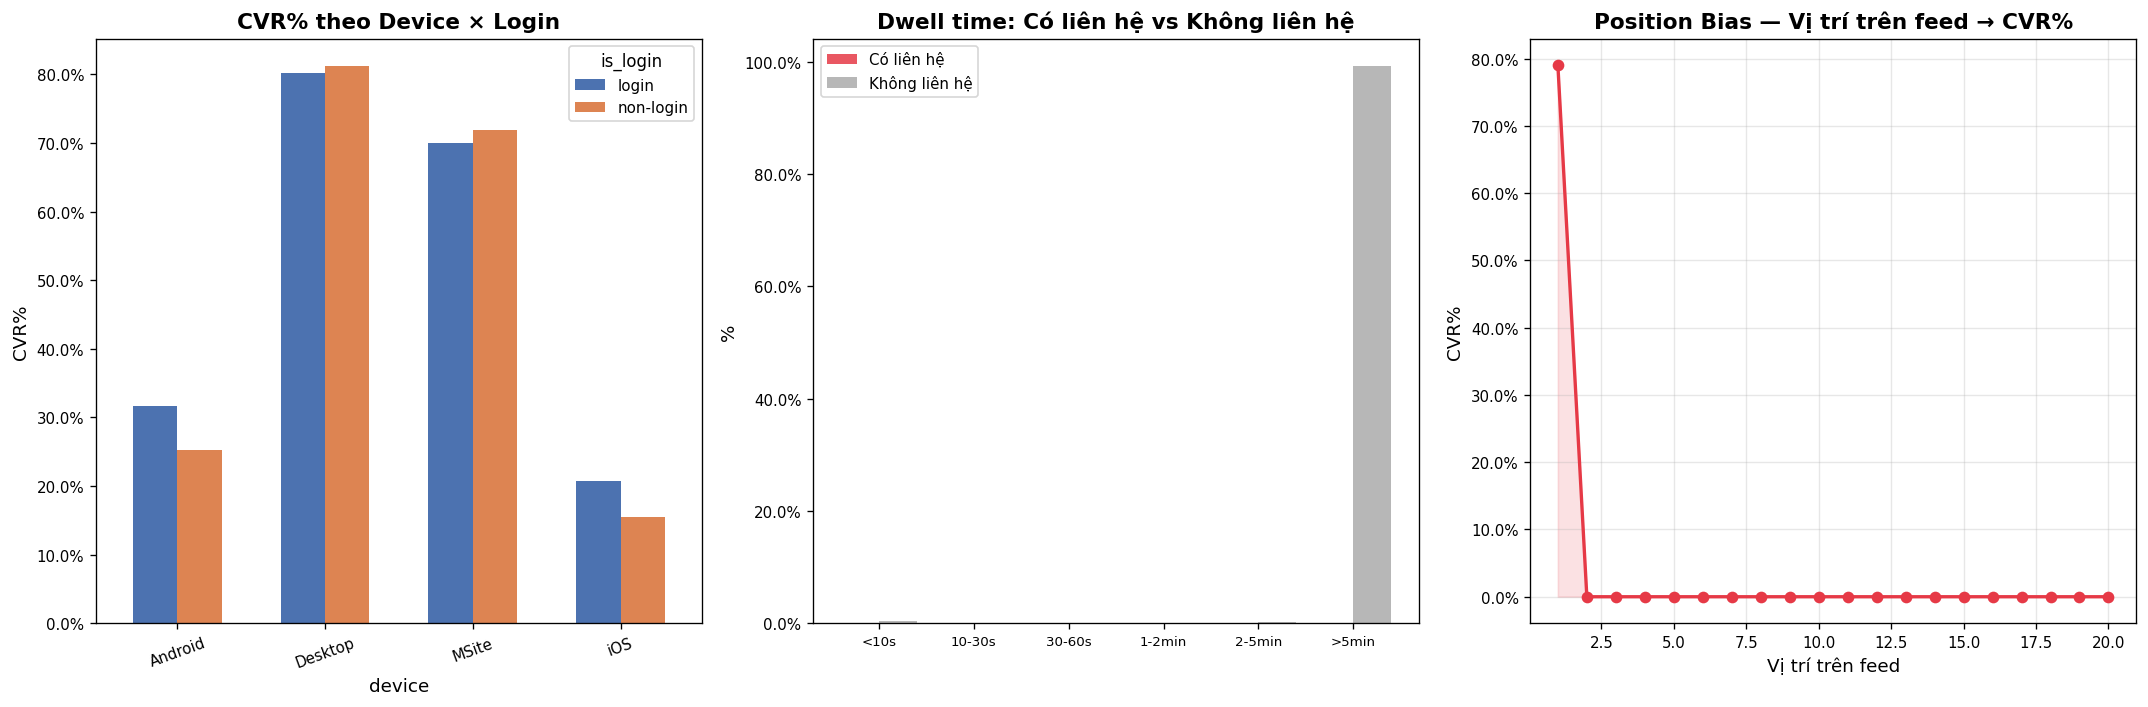

  Saved: /Users/ngoquanghuy/Documents/Datathon_Data/outputs/1050/z5_device_dwell_position.png


In [15]:
# ZONE 5.4 — Device × Login CVR% + Dwell time + Position bias
fig,axes=plt.subplots(1,3,figsize=(18,6))

# Device x login CVR%
dl = ev.groupby(['device','is_login']).agg(total=('event_type','count'),pos=('is_contact','sum')).reset_index()
dl['cvr'] = dl['pos']/dl['total']*100
piv = dl.pivot_table(index='device',columns='is_login',values='cvr',aggfunc='first').fillna(0)
ax=axes[0]
piv.plot(kind='bar',ax=ax,color=['#4C72B0','#DD8452'],width=0.6,rot=20)
ax.yaxis.set_major_formatter(plt.FuncFormatter(pct_fmt))
ax.set_title('CVR% theo Device × Login',fontweight='bold'); ax.set_ylabel('CVR%'); ax.legend(title='is_login',fontsize=9)

# Dwell time
ord_d=['<10s','10-30s','30-60s','1-2min','2-5min','>5min']
dw_c=ev[ev['is_contact']==1]['dwell_bucket'].value_counts(normalize=True).mul(100).reindex(ord_d).fillna(0)
dw_n=ev[ev['is_contact']==0]['dwell_bucket'].value_counts(normalize=True).mul(100).reindex(ord_d).fillna(0)
ax=axes[1]; x=np.arange(len(ord_d)); w=0.4
ax.bar(x-w/2,dw_c.values,w,color=CAT_COLORS[CAT_FOCUS],alpha=0.85,label='Có liên hệ')
ax.bar(x+w/2,dw_n.values,w,color='#999',alpha=0.7,label='Không liên hệ')
ax.set_xticks(x); ax.set_xticklabels(ord_d,fontsize=8)
ax.yaxis.set_major_formatter(plt.FuncFormatter(pct_fmt))
ax.set_title('Dwell time: Có liên hệ vs Không liên hệ',fontweight='bold'); ax.set_ylabel('%'); ax.legend(fontsize=9)

# Position bias
pos_d = ev[ev['pos_bucket']>0].groupby('pos_bucket').agg(total=('event_type','count'),pos=('is_contact','sum')).reset_index()
pos_d['cvr'] = pos_d['pos']/pos_d['total']*100
pos_d = pos_d[pos_d['pos_bucket']<=20].sort_values('pos_bucket')
ax=axes[2]
ax.plot(pos_d['pos_bucket'],pos_d['cvr'],marker='o',color=CAT_COLORS[CAT_FOCUS],lw=2)
ax.fill_between(pos_d['pos_bucket'],pos_d['cvr'],alpha=0.15,color=CAT_COLORS[CAT_FOCUS])
ax.yaxis.set_major_formatter(plt.FuncFormatter(pct_fmt))
ax.set_title('Position Bias — Vị trí trên feed → CVR%',fontweight='bold')
ax.set_xlabel('Vị trí trên feed'); ax.set_ylabel('CVR%'); ax.grid(alpha=0.3)

plt.tight_layout(); save_fig("z5_device_dwell_position.png")

---
# ZONE 6 — Interaction Analysis (fact_post_contact_interactions)

In [16]:
# ZONE 6.1 — Load interactions 1050
print("Query fact_post_contact_interactions category=1050...")
t0 = time.time()
con = duckdb.connect(); con.execute("SET memory_limit='6GB'; SET threads=4")
sql6 = ("SELECT user_id, item_id, date, adview_count, lead_count,"
        " chat_message_count, chat_turn_count, chat_lead, purchased"
        " FROM read_parquet('" + INTER_PATH + "*.parquet')"
        " WHERE category = " + str(CAT_FOCUS))
df_inter = con.execute(sql6).df(); con.close()
print(f"Loaded {len(df_inter):,} rows | {time.time()-t0:.0f}s")

Query fact_post_contact_interactions category=1050...
Loaded 6,994,585 rows | 8s


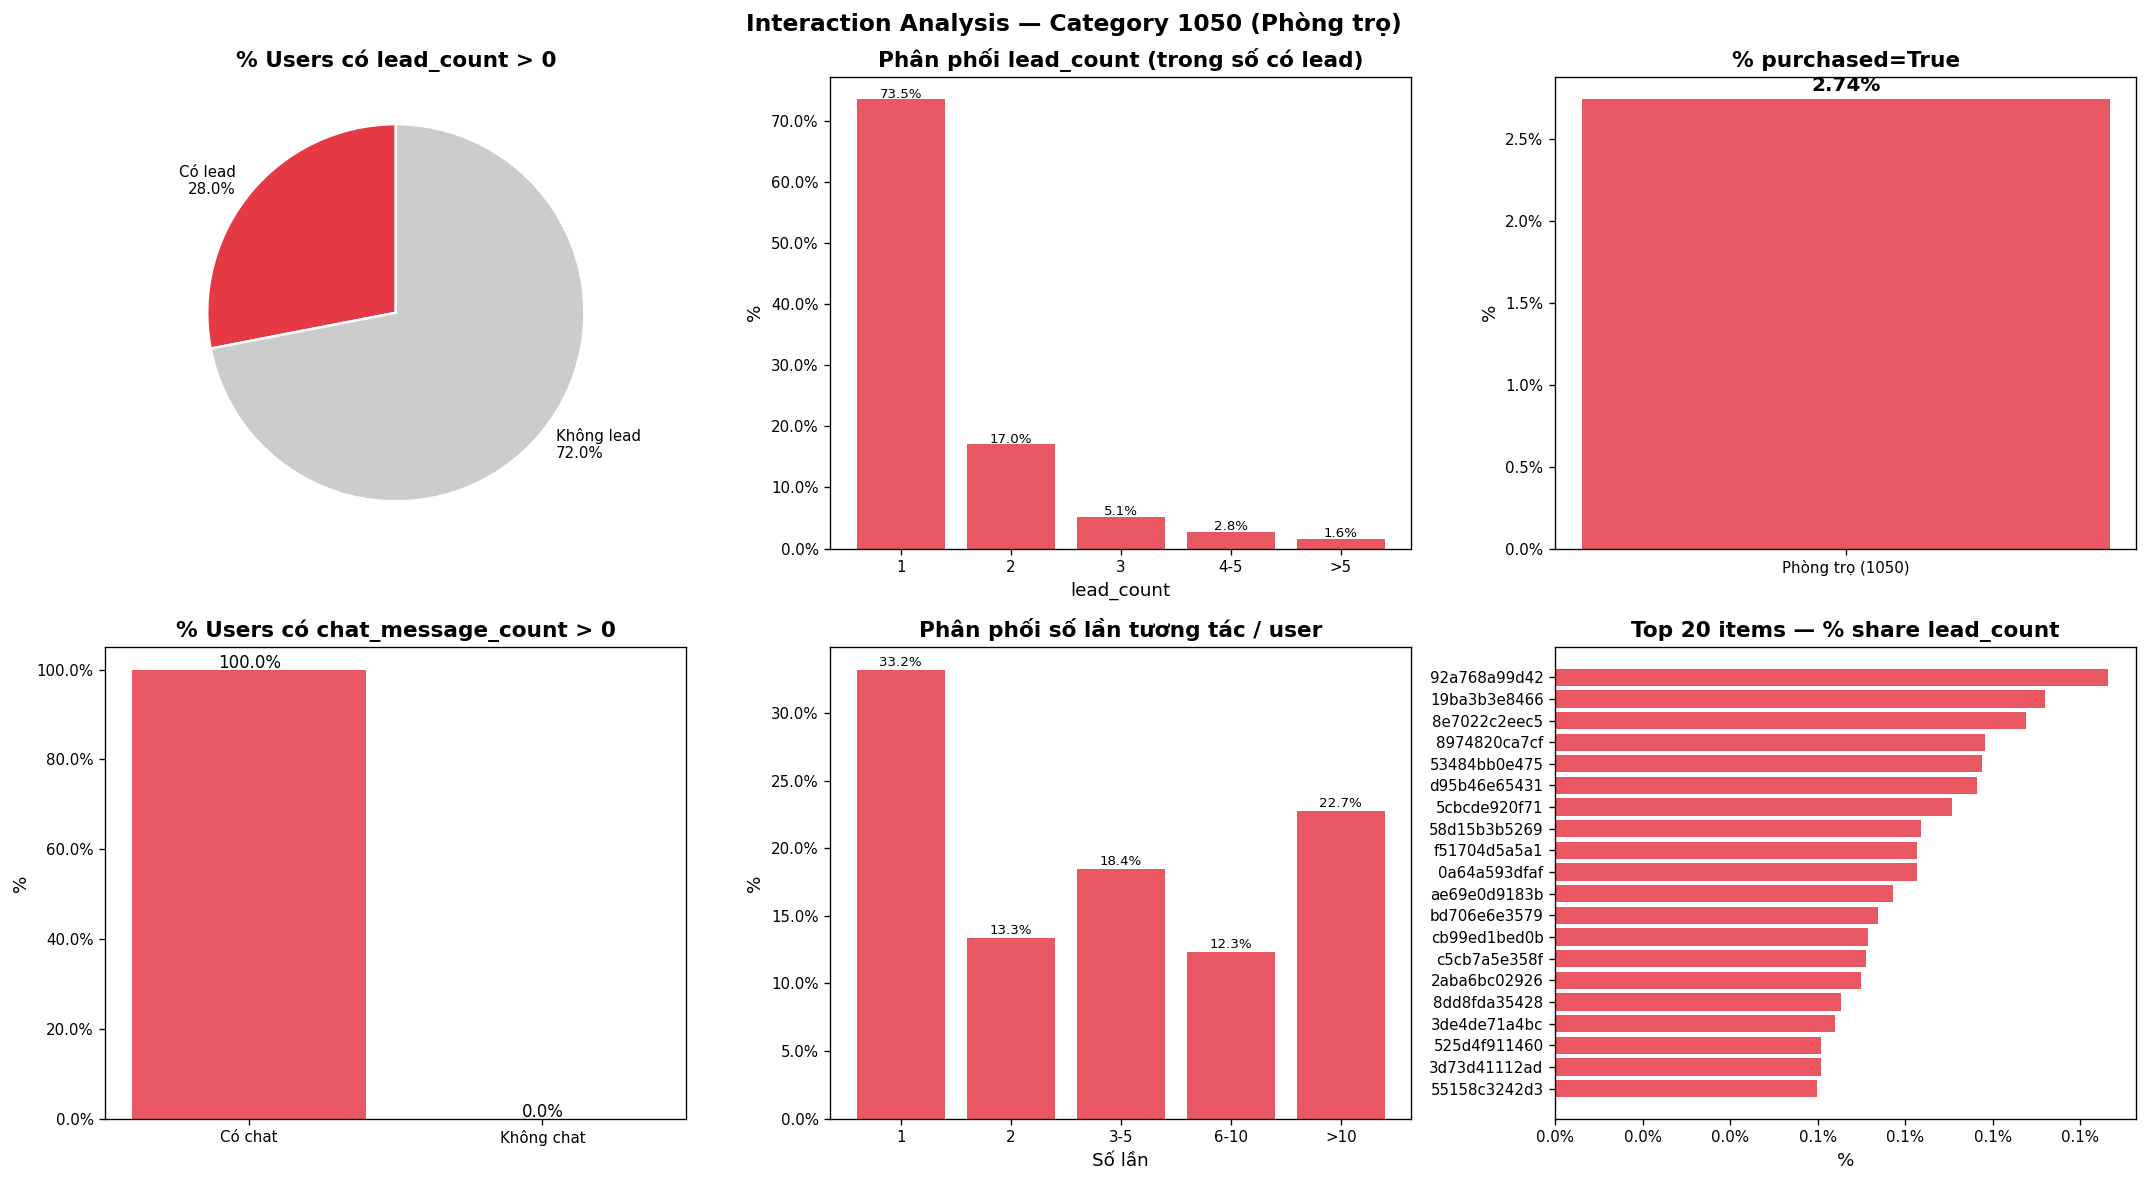

  Saved: /Users/ngoquanghuy/Documents/Datathon_Data/outputs/1050/z6_interactions.png
  Saved: /Users/ngoquanghuy/Documents/Datathon_Data/outputs/1050/z6_interaction_stats.csv


In [17]:
# ZONE 6.2 — Lead, chat, purchased metrics
fig,axes=plt.subplots(2,3,figsize=(18,10))
fig.suptitle(f'Interaction Analysis — Category {CAT_FOCUS} ({CAT_NAME})',fontweight='bold',fontsize=14)

# % users có lead
users_l = df_inter.groupby('user_id')['lead_count'].sum()
has_lead = (users_l>0).mean()*100; no_lead = 100-has_lead
ax=axes[0,0]
ax.pie([has_lead,no_lead],labels=[f'Có lead\n{has_lead:.1f}%',f'Không lead\n{no_lead:.1f}%'],
       colors=[CAT_COLORS[CAT_FOCUS],'#ccc'],startangle=90,wedgeprops={'edgecolor':'white','linewidth':1.5})
ax.set_title('% Users có lead_count > 0',fontweight='bold')

# Lead distribution %
ax=axes[0,1]
inter_l = df_inter[df_inter['lead_count']>0]
lb=['1','2','3','4-5','>5']
lp=pd.cut(inter_l['lead_count'],[0,1,2,3,5,1e9],labels=lb).value_counts(normalize=True).mul(100).reindex(lb)
bars=ax.bar(lb,lp.values,color=CAT_COLORS[CAT_FOCUS],alpha=0.85)
[ax.text(b.get_x()+b.get_width()/2,v+0.3,f"{v:.1f}%",ha='center',fontsize=8) for b,v in zip(bars,lp.values) if not np.isnan(v)]
ax.yaxis.set_major_formatter(plt.FuncFormatter(pct_fmt))
ax.set_title('Phân phối lead_count (trong số có lead)',fontweight='bold'); ax.set_ylabel('%'); ax.set_xlabel('lead_count')

# Purchased rate
ax=axes[0,2]
pur_rate = df_inter['purchased'].mean()*100
ax.bar([f'{CAT_NAME} (1050)'],[pur_rate],color=CAT_COLORS[CAT_FOCUS],alpha=0.85,width=0.4)
ax.text(0,pur_rate+0.05,f"{pur_rate:.2f}%",ha='center',fontsize=12,fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(pct_fmt))
ax.set_title('% purchased=True',fontweight='bold'); ax.set_ylabel('%')

# Chat engagement
ax=axes[1,0]
has_chat=(df_inter['chat_message_count']>0).mean()*100; no_chat=100-has_chat
ax.bar(['Có chat','Không chat'],[has_chat,no_chat],color=[CAT_COLORS[CAT_FOCUS],'#ccc'],alpha=0.85)
[ax.text(i,v+0.3,f"{v:.1f}%",ha='center',fontsize=10) for i,v in enumerate([has_chat,no_chat])]
ax.yaxis.set_major_formatter(plt.FuncFormatter(pct_fmt))
ax.set_title('% Users có chat_message_count > 0',fontweight='bold'); ax.set_ylabel('%')

# User repeat behavior
ax=axes[1,1]
ur=df_inter.groupby('user_id').size().reset_index(name='n')
rp=['1','2','3-5','6-10','>10']
rpp=pd.cut(ur['n'],[0,1,2,5,10,1e9],labels=rp).value_counts(normalize=True).mul(100).reindex(rp)
bars=ax.bar(rp,rpp.values,color=CAT_COLORS[CAT_FOCUS],alpha=0.85)
[ax.text(b.get_x()+b.get_width()/2,v+0.3,f"{v:.1f}%",ha='center',fontsize=8) for b,v in zip(bars,rpp.values) if not np.isnan(v)]
ax.yaxis.set_major_formatter(plt.FuncFormatter(pct_fmt))
ax.set_title('Phân phối số lần tương tác / user',fontweight='bold'); ax.set_ylabel('%'); ax.set_xlabel('Số lần')

# Top 20 items by lead share
ax=axes[1,2]
top_items=df_inter.groupby('item_id')['lead_count'].sum().nlargest(20).reset_index()
top_items['pct_share']=top_items['lead_count']/df_inter['lead_count'].sum()*100
top_items=top_items.sort_values('pct_share')
ax.barh(top_items['item_id'].str[:12],top_items['pct_share'],color=CAT_COLORS[CAT_FOCUS],alpha=0.85)
ax.xaxis.set_major_formatter(plt.FuncFormatter(pct_fmt))
ax.set_title('Top 20 items — % share lead_count',fontweight='bold'); ax.set_xlabel('%')

plt.tight_layout(); save_fig("z6_interactions.png")
stats6={'users_total':df_inter['user_id'].nunique(),'users_with_lead_pct':round(has_lead,2),
        'users_with_chat_pct':round(has_chat,2),'purchased_true_pct':round(pur_rate,2),
        'total_leads':int(df_inter['lead_count'].sum())}
save_csv(pd.DataFrame([stats6]),"z6_interaction_stats.csv")

---
# ZONE 7 — Supply-Demand Gap & Geo Hotspots

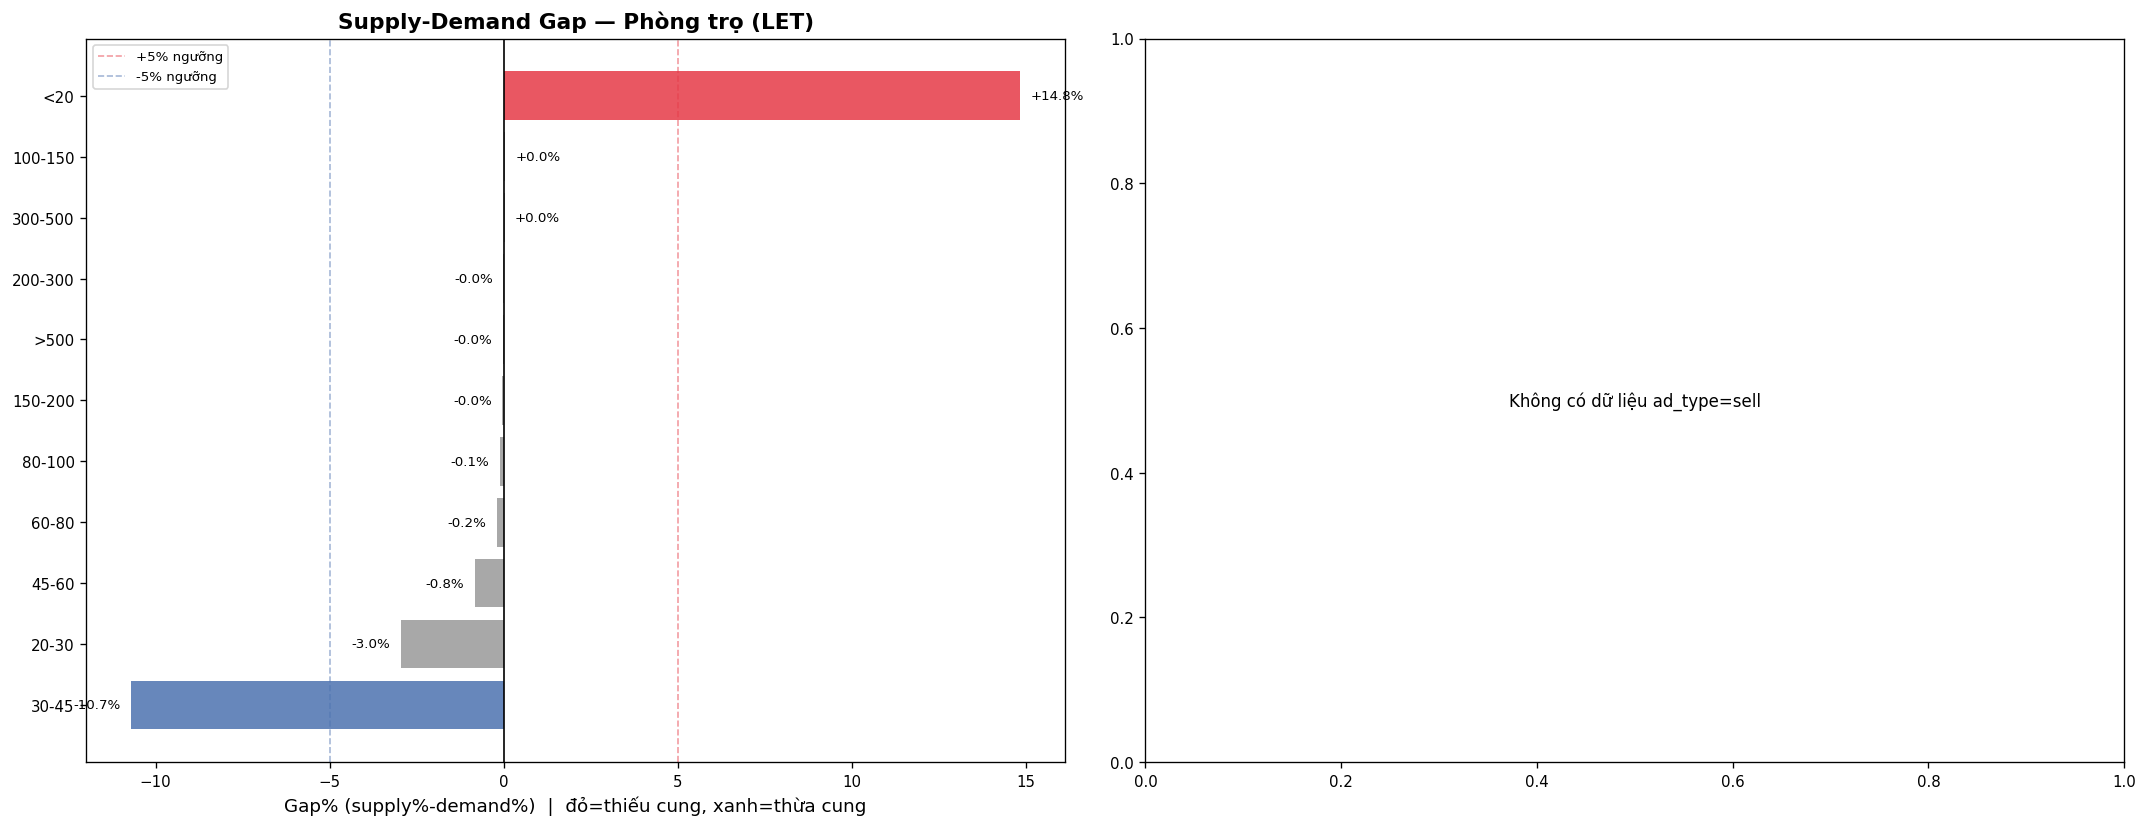

  Saved: /Users/ngoquanghuy/Documents/Datathon_Data/outputs/1050/z7_area_gap.png
  Saved: /Users/ngoquanghuy/Documents/Datathon_Data/outputs/1050/z7_gap_1050.csv


In [18]:
# ZONE 7.1 — Area gap + City supply vs demand
gap_df = pd.read_csv(BASE+"/outputs/supply_demand_gap.csv")
gap_1050 = gap_df[gap_df['category']==CAT_FOCUS].copy()

fig,axes=plt.subplots(1,2,figsize=(18,7))
for ax,ad_type in zip(axes,['let','sell']):
    sub=gap_1050[gap_1050['ad_type']==ad_type].sort_values('gap',ascending=True)
    if len(sub)==0: ax.text(0.5,0.5,f'Không có dữ liệu ad_type={ad_type}',ha='center',va='center',transform=ax.transAxes); continue
    gc_list=['#E63946' if g>5 else '#4C72B0' if g<-5 else '#999' for g in sub['gap']]
    bars=ax.barh(sub['area_bucket'],sub['gap'],color=gc_list,alpha=0.85)
    ax.axvline(0,color='black',lw=1)
    ax.axvline(5, color='#E63946',lw=1,ls='--',alpha=0.5,label='+5% ngưỡng')
    ax.axvline(-5,color='#4C72B0',lw=1,ls='--',alpha=0.5,label='-5% ngưỡng')
    [ax.text(v+(0.3 if v>=0 else -0.3),b.get_y()+b.get_height()/2,f"{v:+.1f}%",va='center',
             ha='left' if v>=0 else 'right',fontsize=8) for b,v in zip(bars,sub['gap'])]
    ax.set_title(f'Supply-Demand Gap — {CAT_NAME} ({ad_type.upper()})',fontweight='bold')
    ax.set_xlabel('Gap% (supply%-demand%)  |  đỏ=thiếu cung, xanh=thừa cung'); ax.legend(fontsize=8)

plt.tight_layout(); save_fig("z7_area_gap.png")
save_csv(gap_1050,"z7_gap_1050.csv")

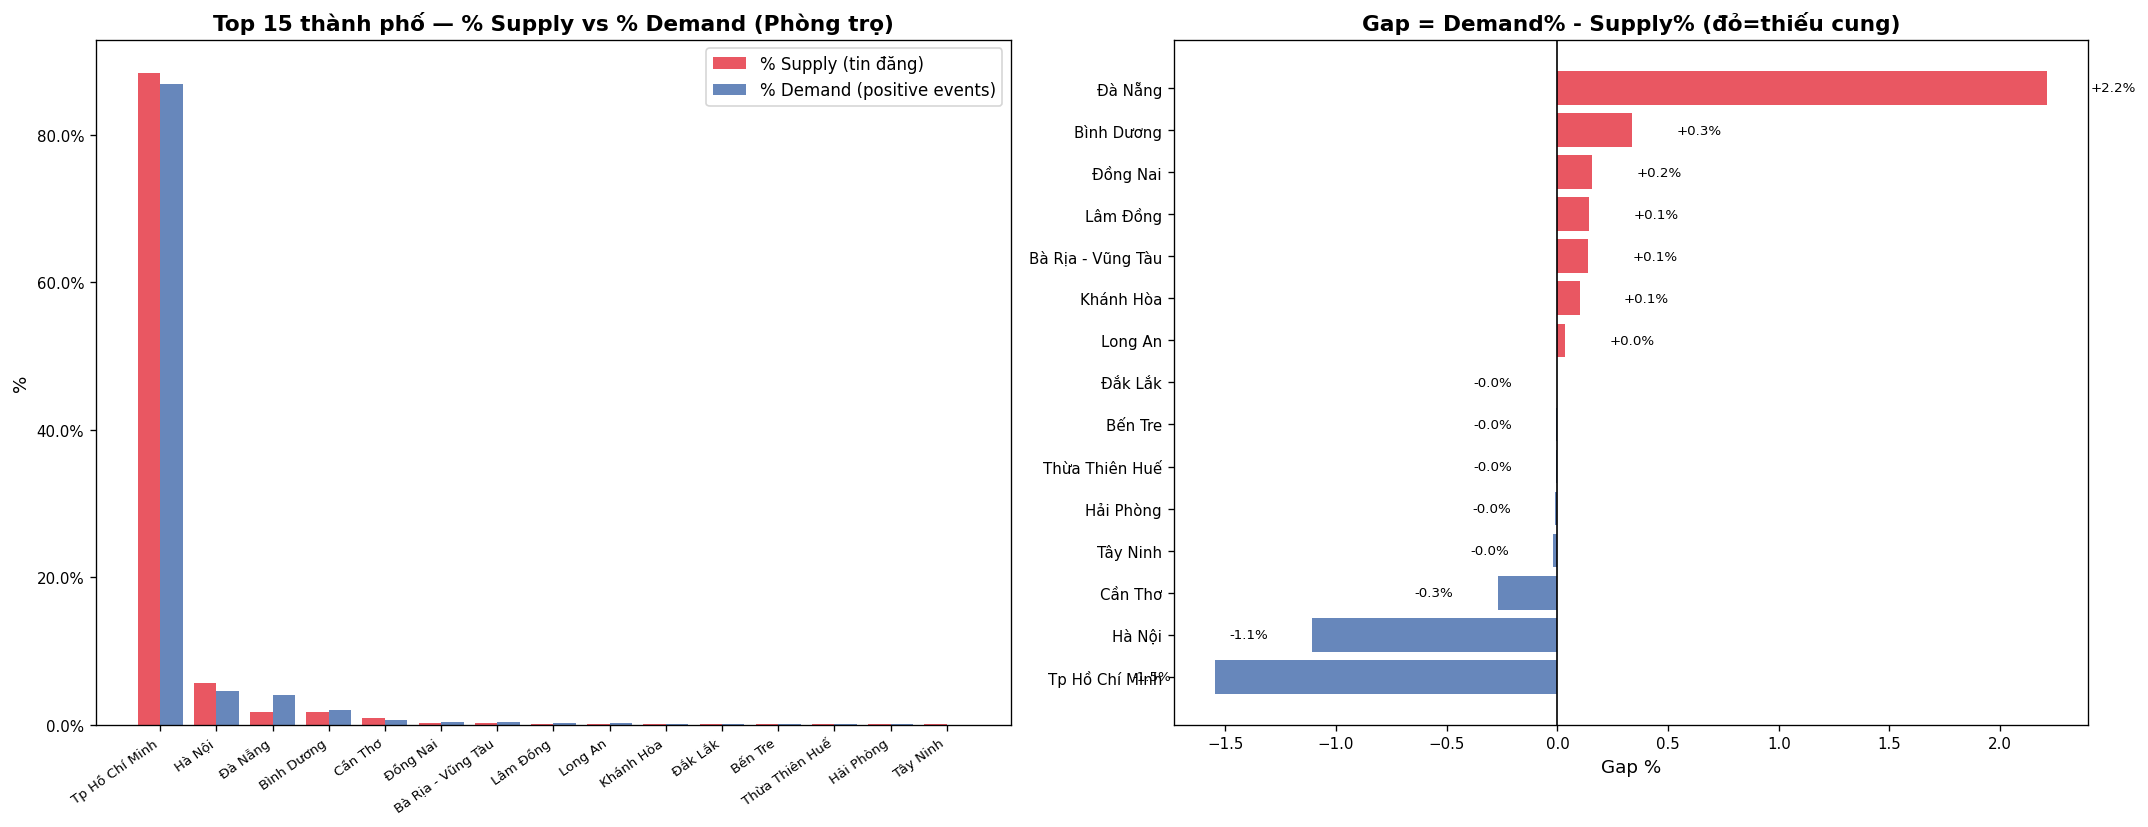

  Saved: /Users/ngoquanghuy/Documents/Datathon_Data/outputs/1050/z7_city_supply_demand.png
  Saved: /Users/ngoquanghuy/Documents/Datathon_Data/outputs/1050/z7_city_gap.csv


In [19]:
# ZONE 7.2 — City supply vs demand
supply_city = df_dim_focus['city_name'].value_counts(normalize=True).mul(100).reset_index()
supply_city.columns=['city_name','supply_pct']

geo_cvr = pd.read_csv(BASE+"/outputs/geo_cvr.csv")
geo_1050= geo_cvr[geo_cvr['category']==CAT_FOCUS].copy()
dem = geo_1050.groupby('city_name')['pos'].sum().reset_index()
dem['demand_pct'] = dem['pos']/dem['pos'].sum()*100

merged = supply_city.merge(dem[['city_name','demand_pct']],on='city_name',how='outer').fillna(0)
merged['gap'] = merged['demand_pct']-merged['supply_pct']
merged = merged.sort_values('demand_pct',ascending=False).head(15)

fig,axes=plt.subplots(1,2,figsize=(18,7))

ax=axes[0]; x=np.arange(len(merged)); w=0.4
ax.bar(x-w/2,merged['supply_pct'],w,color=CAT_COLORS[CAT_FOCUS],alpha=0.85,label='% Supply (tin đăng)')
ax.bar(x+w/2,merged['demand_pct'],w,color='#4C72B0',alpha=0.85,label='% Demand (positive events)')
ax.set_xticks(x); ax.set_xticklabels(merged['city_name'],rotation=35,ha='right',fontsize=8)
ax.yaxis.set_major_formatter(plt.FuncFormatter(pct_fmt))
ax.set_title(f'Top 15 thành phố — % Supply vs % Demand ({CAT_NAME})',fontweight='bold')
ax.set_ylabel('%'); ax.legend()

ax=axes[1]
ms=merged.sort_values('gap')
gc2=['#E63946' if g>0 else '#4C72B0' for g in ms['gap']]
bars=ax.barh(ms['city_name'],ms['gap'],color=gc2,alpha=0.85)
ax.axvline(0,color='black',lw=1)
[ax.text(v+(0.2 if v>=0 else -0.2),b.get_y()+b.get_height()/2,f"{v:+.1f}%",va='center',
         ha='left' if v>=0 else 'right',fontsize=8) for b,v in zip(bars,ms['gap'])]
ax.set_title('Gap = Demand% - Supply% (đỏ=thiếu cung)',fontweight='bold'); ax.set_xlabel('Gap %')

plt.tight_layout(); save_fig("z7_city_supply_demand.png")
save_csv(merged,"z7_city_gap.csv")

---
# ZONE 8 — Decay & Lifecycle Analysis

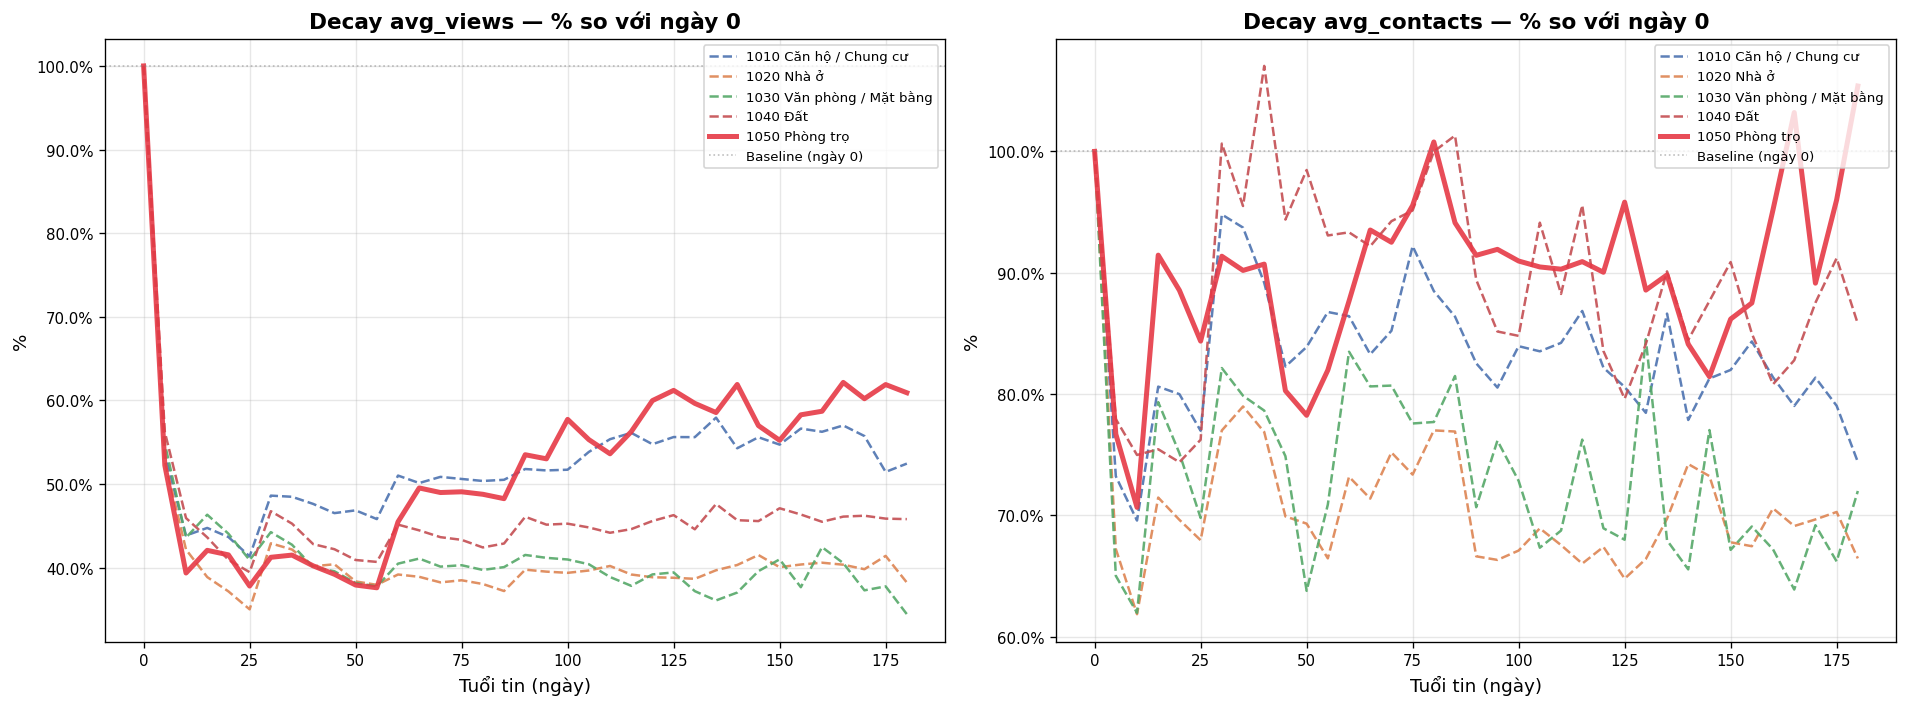

  Saved: /Users/ngoquanghuy/Documents/Datathon_Data/outputs/1050/z8_decay_curve.png


In [20]:
# ZONE 8.1 — Decay curve so sánh 5 category
decay = pd.read_csv(BASE+"/outputs/s3_decay.csv")

fig,axes=plt.subplots(1,2,figsize=(16,6))
for ax,metric in [(axes[0],'avg_views'),(axes[1],'avg_contacts')]:
    for cat_id,cat_name in CAT_MAPPING.items():
        sub=decay[decay['category']==cat_id].sort_values('age_bucket')
        if sub.empty: continue
        base=sub[metric].iloc[0]
        if base==0: continue
        pct=sub[metric]/base*100
        lw=3 if cat_id==CAT_FOCUS else 1.5
        ls='-' if cat_id==CAT_FOCUS else '--'
        ax.plot(sub['age_bucket'],pct,lw=lw,ls=ls,color=CAT_COLORS[cat_id],
                label=f"{cat_id} {cat_name}",alpha=0.9)
    ax.axhline(100,color='gray',lw=1,ls=':',alpha=0.5,label='Baseline (ngày 0)')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(pct_fmt))
    ax.set_title(f'Decay {metric} — % so với ngày 0',fontweight='bold')
    ax.set_xlabel('Tuổi tin (ngày)'); ax.set_ylabel('%'); ax.legend(fontsize=8,loc='upper right'); ax.grid(alpha=0.3)

plt.tight_layout(); save_fig("z8_decay_curve.png")

Query fact_listing_snapshot cho 1050...
Loaded 1,284,923 snapshot rows | 2.4s


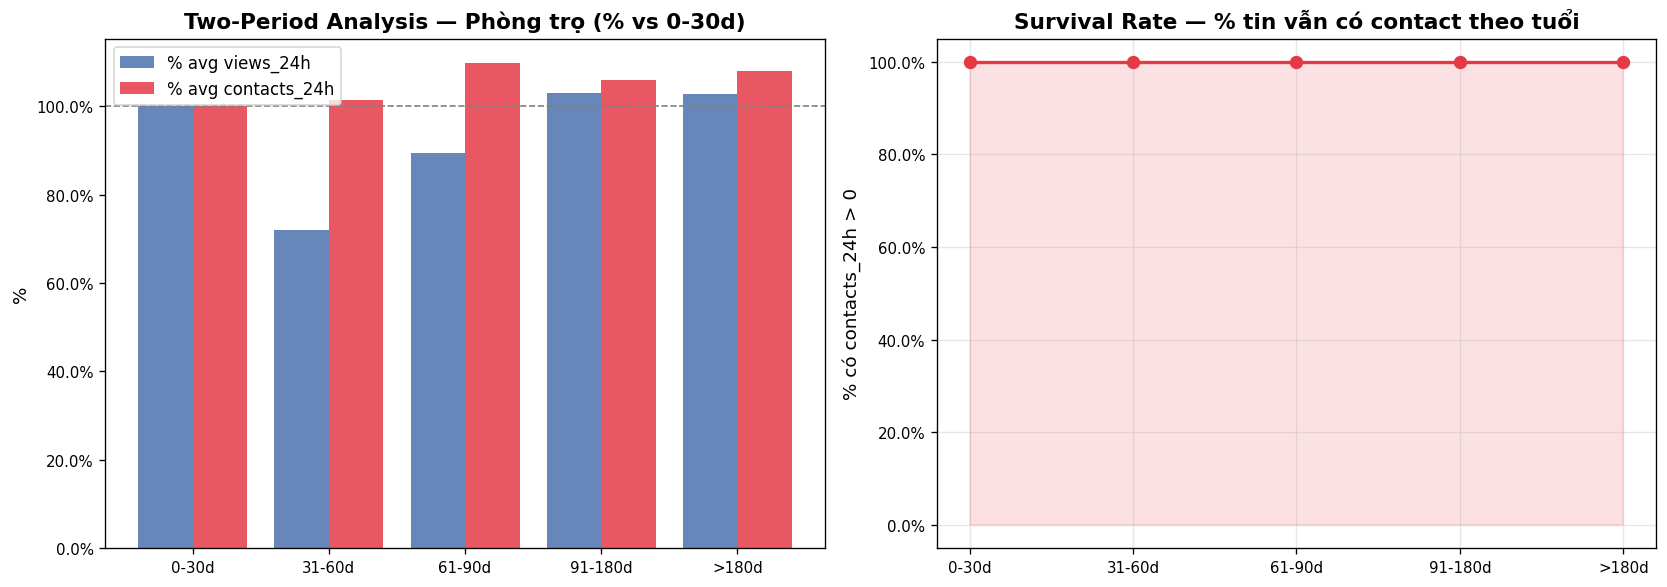

  Saved: /Users/ngoquanghuy/Documents/Datathon_Data/outputs/1050/z8_lifecycle.png
  Saved: /Users/ngoquanghuy/Documents/Datathon_Data/outputs/1050/z8_lifecycle_stats.csv


In [21]:
# ZONE 8.2 — Snapshot: Two-period analysis + Survival rate
print("Query fact_listing_snapshot cho 1050...")
t0 = time.time()
con = duckdb.connect(); con.execute("SET memory_limit='5GB'; SET threads=4")

ids50 = list(cat_sets[CAT_FOCUS])[:50000]
ids_str = "','".join(ids50)

sql8 = ("SELECT item_id, listing_age_days, views_24h, contacts_24h"
        " FROM read_parquet('" + SNAP_PATH + "*.parquet')"
        " WHERE item_id IN ('" + ids_str + "')")
snap50 = con.execute(sql8).df(); con.close()
print(f"Loaded {len(snap50):,} snapshot rows | {time.time()-t0:.1f}s")

if len(snap50)>0:
    snap50['age_bucket']=pd.cut(snap50['listing_age_days'],[0,30,60,90,180,1e9],
                                labels=['0-30d','31-60d','61-90d','91-180d','>180d'])
    ps = snap50.groupby('age_bucket').agg(avg_v=('views_24h','mean'),avg_c=('contacts_24h','mean'),n=('item_id','nunique')).reset_index()
    b0_v = ps['avg_v'].iloc[0] if ps['avg_v'].iloc[0]>0 else 1
    b0_c = ps['avg_c'].iloc[0] if ps['avg_c'].iloc[0]>0 else 1
    ps['views_pct']    = ps['avg_v']/b0_v*100
    ps['contacts_pct'] = ps['avg_c']/b0_c*100
    surv = snap50.groupby('age_bucket').apply(lambda g:(g['contacts_24h']>0).mean()*100).reset_index(name='survival_pct')

    fig,axes=plt.subplots(1,2,figsize=(14,5))
    ax=axes[0]; x=np.arange(len(ps)); w=0.4
    ax.bar(x-w/2,ps['views_pct'],   w,color='#4C72B0',alpha=0.85,label='% avg views_24h')
    ax.bar(x+w/2,ps['contacts_pct'],w,color=CAT_COLORS[CAT_FOCUS],alpha=0.85,label='% avg contacts_24h')
    ax.set_xticks(x); ax.set_xticklabels(ps['age_bucket'].astype(str),fontsize=9)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(pct_fmt))
    ax.axhline(100,color='gray',ls='--',lw=1)
    ax.set_title(f'Two-Period Analysis — {CAT_NAME} (% vs 0-30d)',fontweight='bold')
    ax.set_ylabel('%'); ax.legend()

    ax=axes[1]
    ax.plot(range(len(surv)),surv['survival_pct'],marker='o',color=CAT_COLORS[CAT_FOCUS],lw=2,markersize=7)
    ax.fill_between(range(len(surv)),surv['survival_pct'],alpha=0.15,color=CAT_COLORS[CAT_FOCUS])
    ax.set_xticks(range(len(surv))); ax.set_xticklabels(surv['age_bucket'].astype(str),fontsize=9)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(pct_fmt))
    ax.set_title(f'Survival Rate — % tin vẫn có contact theo tuổi',fontweight='bold')
    ax.set_ylabel('% có contacts_24h > 0'); ax.grid(alpha=0.3)

    plt.tight_layout(); save_fig("z8_lifecycle.png")
    save_csv(ps,"z8_lifecycle_stats.csv")
else:
    print("Không có snapshot data cho sample 1050")

---
# ZONE 9 — Root Cause Synthesis & Business Recommendations

In [22]:
# ZONE 9 — Tổng hợp issue tree
s2_cvr    = pd.read_csv(BASE+"/outputs/s2_cvr.csv")
s2_funnel = pd.read_csv(BASE+"/outputs/s2_funnel.csv")
s2_dwell  = pd.read_csv(BASE+"/outputs/s2_dwell_time.csv")

cvr_1050  = s2_cvr[s2_cvr['category']==CAT_FOCUS]['CVR'].values[0]
cvr_avg   = s2_cvr['CVR'].mean()
pv_phone  = s2_funnel[s2_funnel['category']==CAT_FOCUS]['pv_to_phone'].values[0]
dwell_1050= s2_dwell[s2_dwell['category']==CAT_FOCUS]['mean_dwell'].values[0]
dwell_avg = s2_dwell['mean_dwell'].mean()

miss_key = {c: round(df_dim_focus[c].isna().mean()*100,1) if c in df_dim_focus.columns else 0
            for c in ['bedrooms','floors','direction','legal_status']}

issues = [
    {"stt":1,"van_de":"CVR thấp hơn average","bang_chung":f"CVR 1050={cvr_1050:.2f}% vs avg={cvr_avg:.2f}%",
     "muc_do":"Medium","root_cause":"Listing thiếu thông tin chi tiết — user không đủ niềm tin liên hệ ngay",
     "khuyen_nghi":"Bổ sung required fields: tiện ích, nội thất, quy định phòng trọ"},
    {"stt":2,"van_de":"Tỷ lệ xem SĐT thấp nhất","bang_chung":f"pv_to_phone={pv_phone:.1f}% (thấp nhất 5 cat)",
     "muc_do":"High","root_cause":"User 1050 ưu tiên nhắn tin/chat hơn gọi điện (phân khúc giá rẻ, tìm kiếm nhanh)",
     "khuyen_nghi":"Tăng CTA nhắn tin/Zalo, đặt nút chat nổi bật hơn phone"},
    {"stt":3,"van_de":"Dwell time thấp nhất","bang_chung":f"Avg={dwell_1050:.1f}s vs avg={dwell_avg:.1f}s",
     "muc_do":"Medium","root_cause":"Trang tin thiếu nội dung: ít ảnh, thiếu mô tả — user thoát nhanh",
     "khuyen_nghi":"Yêu cầu tối thiểu 5 ảnh + template mô tả chuẩn cho phòng trọ"},
    {"stt":4,"van_de":"Missing values cao","bang_chung":str({k:f"{v}%" for k,v in miss_key.items()}),
     "muc_do":"High","root_cause":"Schema hiện tại không phù hợp phân khúc phòng trọ — thiếu fields quan trọng",
     "khuyen_nghi":"Xây schema riêng cho 1050: bỏ fields N/A, thêm: số người ở chung, nội quy, tiện ích gần nhà"},
    {"stt":5,"van_de":"Supply-demand gap theo diện tích","bang_chung":"Xem z7_area_gap.png + z7_gap_1050.csv",
     "muc_do":"High","root_cause":"Cung và cầu lệch nhau theo phân khúc diện tích — user không tìm được tin phù hợp",
     "khuyen_nghi":"Chiến dịch thu hút seller ở phân khúc diện tích thiếu cung nhất"},
    {"stt":6,"van_de":"Tập trung địa lý cao","bang_chung":"TP.HCM chiếm ~70%+ supply và demand",
     "muc_do":"Medium","root_cause":"Tự nhiên nhưng cần expand — các tỉnh công nghiệp (Bình Dương, Đồng Nai) đang thiếu supply",
     "khuyen_nghi":"Seller acquisition ở Bình Dương, Đồng Nai, Hà Nội — chiến dịch cụ thể per city"},
    {"stt":7,"van_de":"Bulk/spam posting","bang_chung":"Xem z4_top_sellers.csv — concentration top 10 sellers",
     "muc_do":"Medium","root_cause":"Một số môi giới đăng hàng trăm tin giống nhau làm loãng feed và giảm chất lượng",
     "khuyen_nghi":"Rate limiting per seller, dedup content detection, ưu tiên tin unique trong ranking"},
]

df_issues = pd.DataFrame(issues)
save_csv(df_issues,"z9_root_cause_summary.csv")

print("\n" + "="*90)
print(f"ISSUE TREE — Category {CAT_FOCUS} ({CAT_NAME})")
print("="*90)
for _,row in df_issues.iterrows():
    print(f"\n#{row['stt']} [{row['muc_do']}] {row['van_de']}")
    print(f"  Bằng chứng : {row['bang_chung']}")
    print(f"  Root cause : {row['root_cause']}")
    print(f"  Khuyến nghị: {row['khuyen_nghi']}")
print("\nDone! Xem outputs/1050/ cho tất cả file.")

  Saved: /Users/ngoquanghuy/Documents/Datathon_Data/outputs/1050/z9_root_cause_summary.csv

ISSUE TREE — Category 1050 (Phòng trọ)

#1 [Medium] CVR thấp hơn average
  Bằng chứng : CVR 1050=54.69% vs avg=57.90%
  Root cause : Listing thiếu thông tin chi tiết — user không đủ niềm tin liên hệ ngay
  Khuyến nghị: Bổ sung required fields: tiện ích, nội thất, quy định phòng trọ

#2 [High] Tỷ lệ xem SĐT thấp nhất
  Bằng chứng : pv_to_phone=4.3% (thấp nhất 5 cat)
  Root cause : User 1050 ưu tiên nhắn tin/chat hơn gọi điện (phân khúc giá rẻ, tìm kiếm nhanh)
  Khuyến nghị: Tăng CTA nhắn tin/Zalo, đặt nút chat nổi bật hơn phone

#3 [Medium] Dwell time thấp nhất
  Bằng chứng : Avg=44.2s vs avg=53.7s
  Root cause : Trang tin thiếu nội dung: ít ảnh, thiếu mô tả — user thoát nhanh
  Khuyến nghị: Yêu cầu tối thiểu 5 ảnh + template mô tả chuẩn cho phòng trọ

#4 [High] Missing values cao
  Bằng chứng : {'bedrooms': '100.0%', 'floors': '100.0%', 'direction': '100.0%', 'legal_status': '100.0%'}
  Root cau

---
# Kết quả Pipeline

| Zone | File output | Nội dung |
|------|-------------|----------|
| Z1 | `z1_timeline_gantt.png`, `z1_data_density.png`, `z1_cut_summary.csv` | Timeline coverage + cắt dữ liệu |
| Z2 | `z2_category_benchmark.png` | Benchmark 5 category |
| Z3 | `z3_missing_values.png`, `z3_supply_structure.png`, `z3_geo_supply.png` | Supply analysis |
| Z4 | `z4_seller.png`, `z4_top_sellers.csv` | Seller analysis |
| Z5 | `z5_funnel.png`, `z5_daily_heatmap.png`, `z5_device_dwell_position.png` | Demand & funnel |
| Z6 | `z6_interactions.png`, `z6_interaction_stats.csv` | Interaction analysis |
| Z7 | `z7_area_gap.png`, `z7_city_supply_demand.png` | Geo & supply-demand gap |
| Z8 | `z8_decay_curve.png`, `z8_lifecycle.png` | Decay & lifecycle |
| Z9 | `z9_root_cause_summary.csv` | Root cause & recommendations |
